<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Visualization_of_Raw_Data_Acquisition_from_Quantum_Computers_with_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install -q "qutip==5.3.1" "cupy-cuda12x>=14,<15"

CuPy GPU acceleration available: True
QuTiP available: True

NUMERICAL STACK
NumPy: 2.0.2
SciPy distribution: 1.16.3
Matplotlib: 3.10.0
CuPy distribution: 14.0.1
QuTiP distribution: 5.3.1
CUDA device available to CuPy: True
QuTiP import healthy: True

PHYSICAL INTERPRETATION
An N-qubit register has Hilbert-space dimension 2^N. A quantum gate is represented mathematically by a unitary transformation, and a physical QPU realizes the dynamics with its Hamiltonian and controls.
A classified measurement shot returns N classical bits before packing. Integrated I/Q records and raw ADC streams carry larger detector payloads, yet neither exposes all 2^N complex state amplitudes.
Exact classical state-vector simulation stores 2^N complex amplitudes. A fully materialized dense N-qubit unitary would store 4^N complex entries, although practical simulators usually apply local gates without constructing that global matrix.
The QuTiP section solves a three-level driven Duffing model only. It demonstr

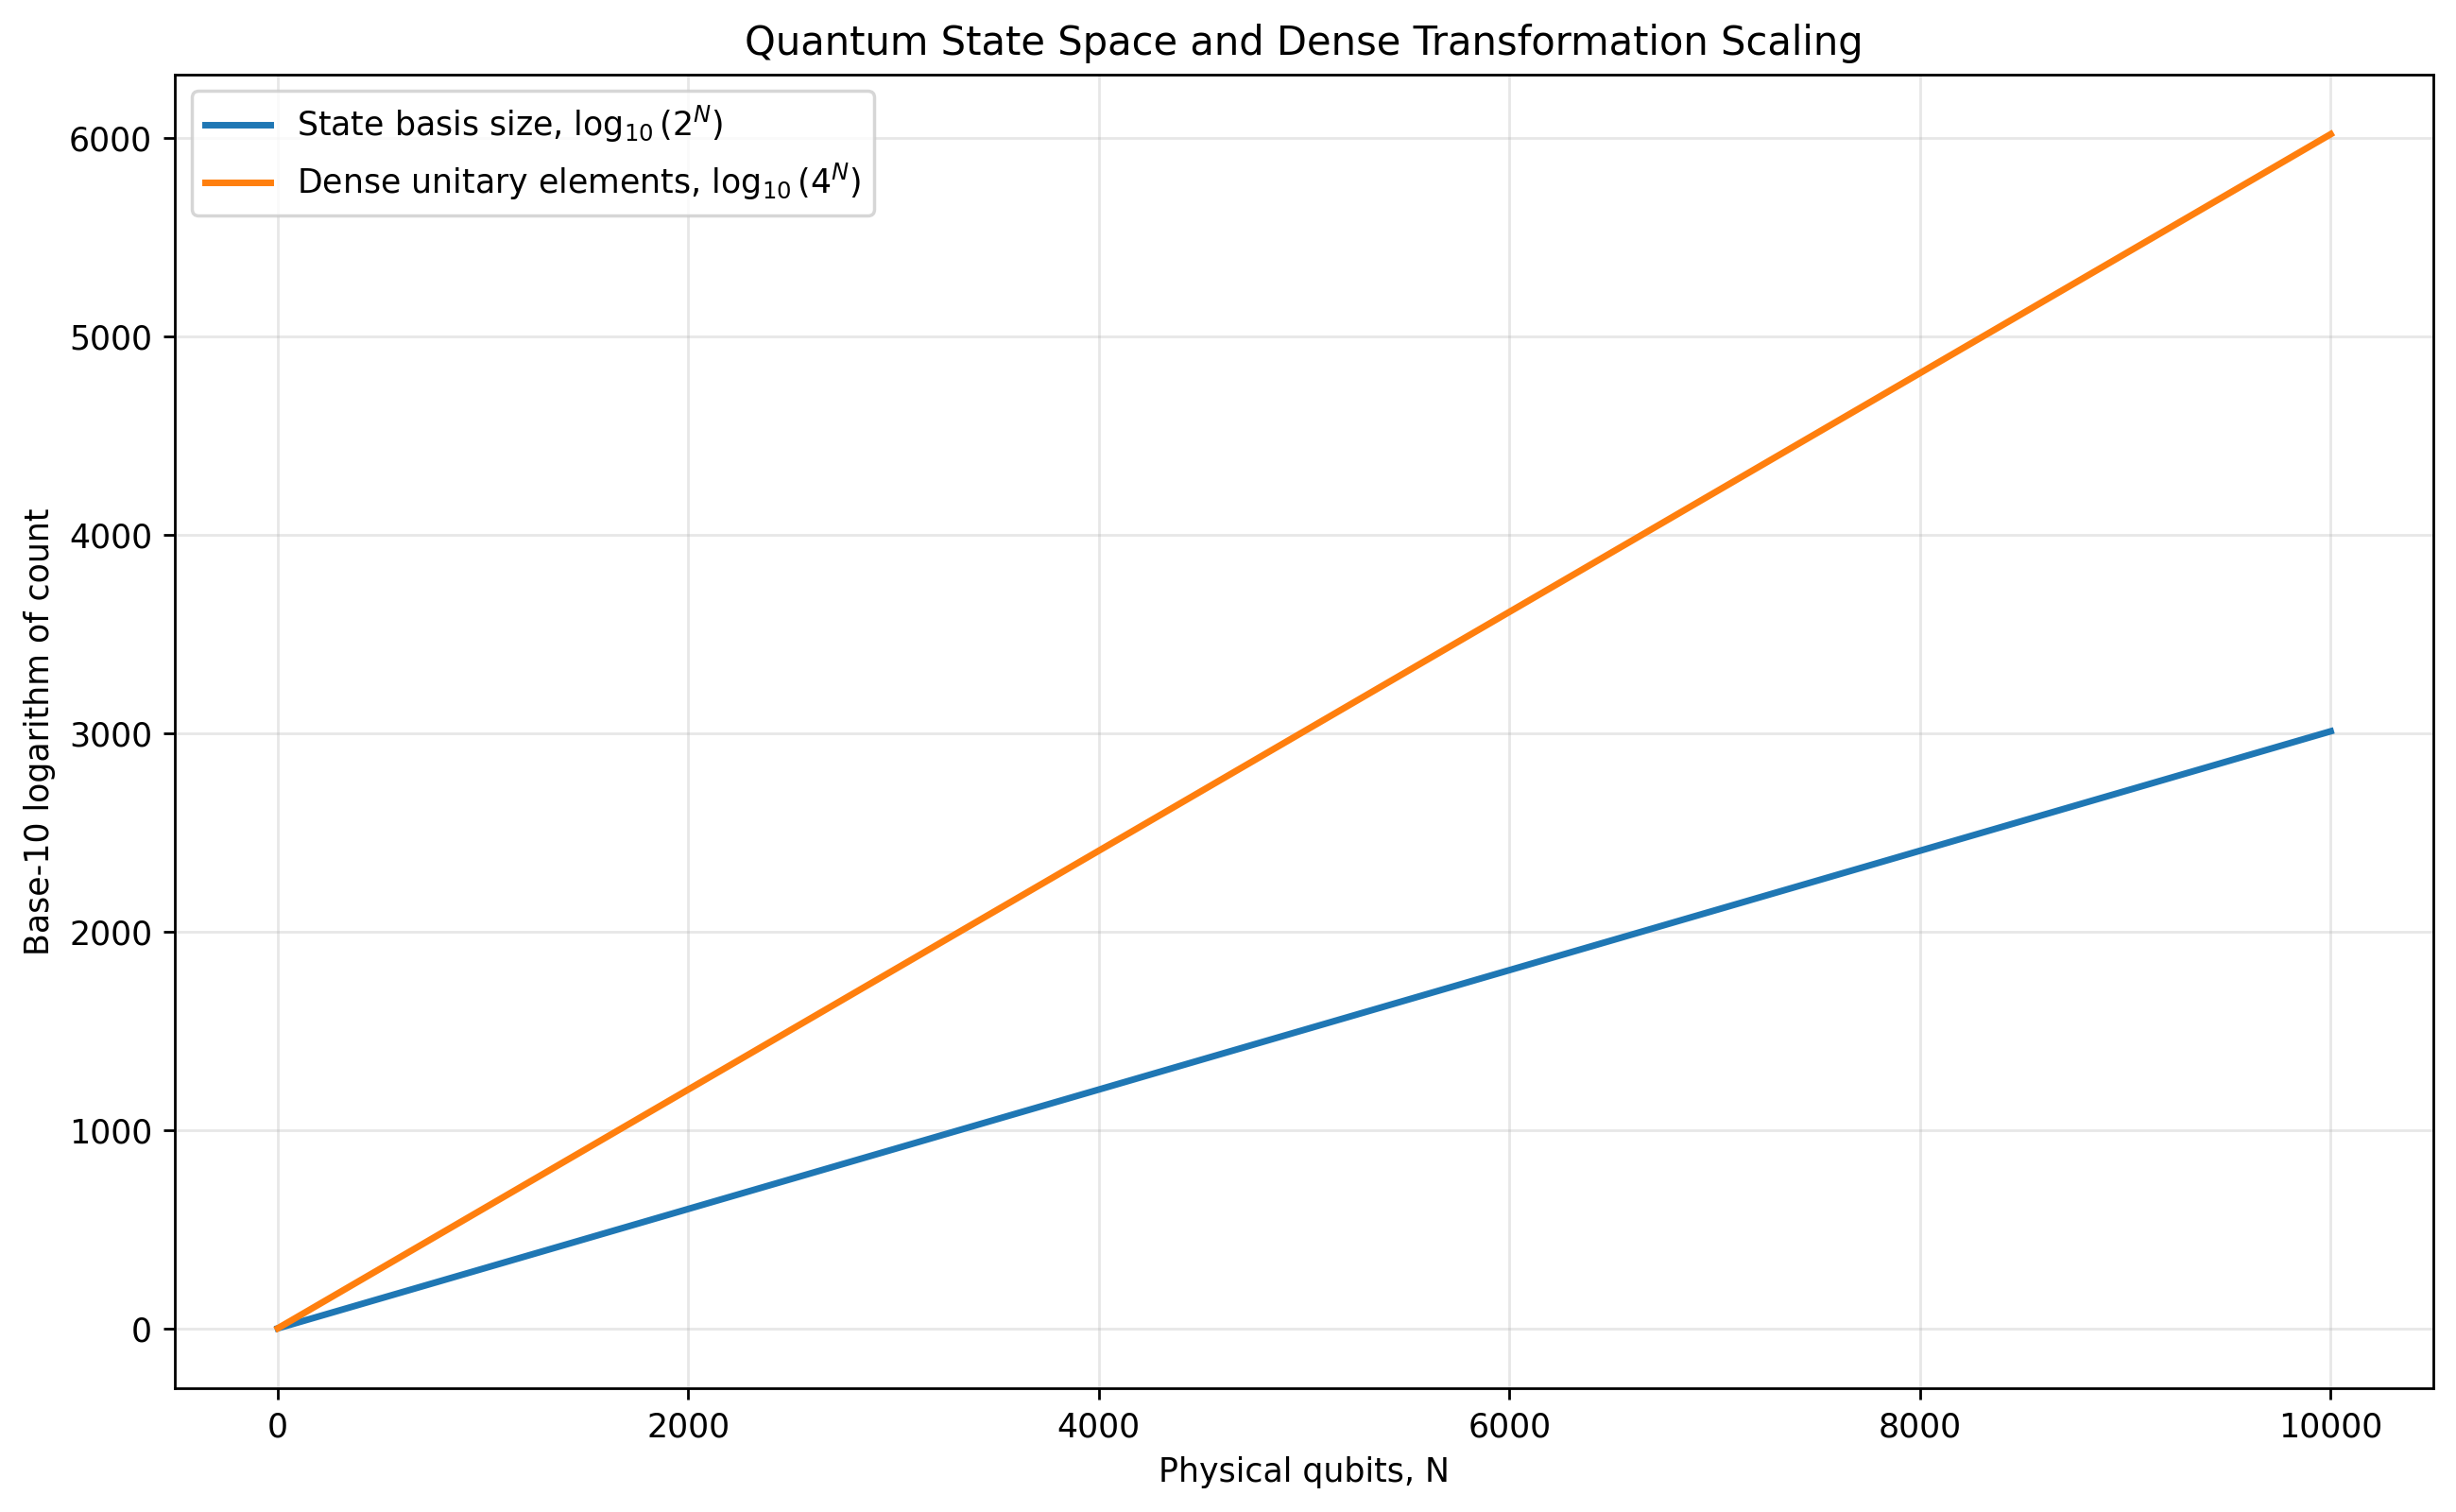

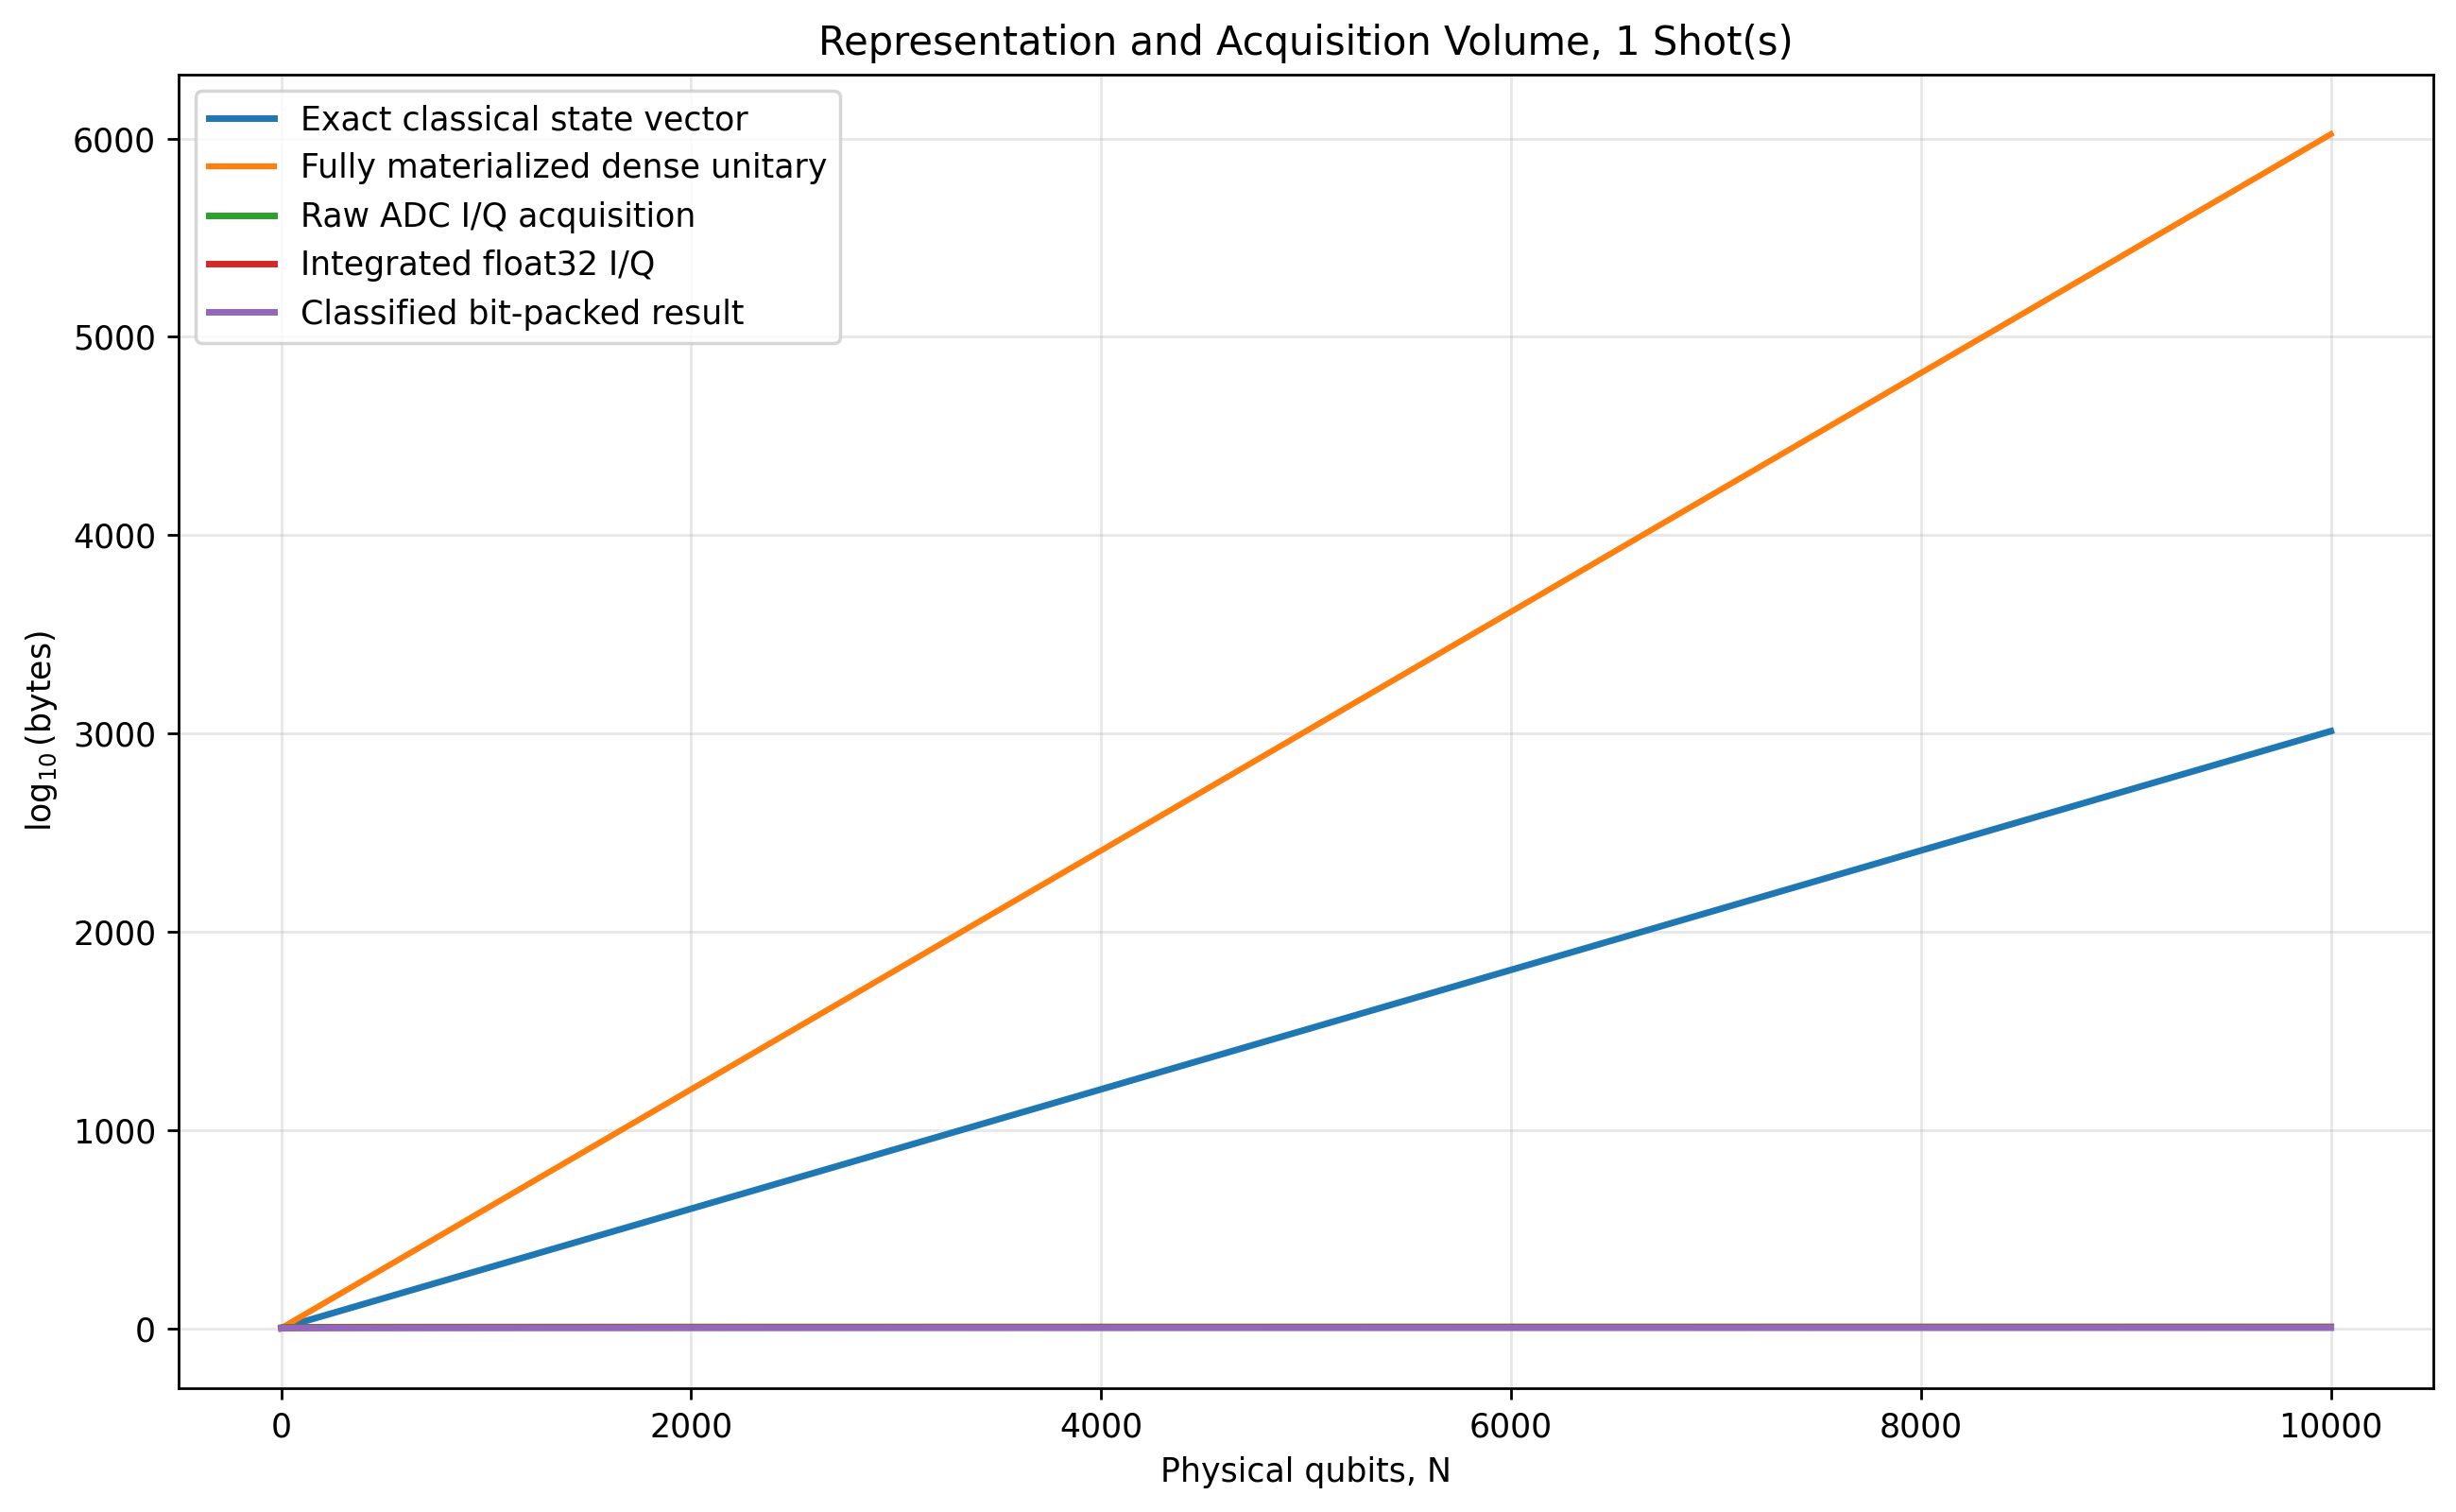

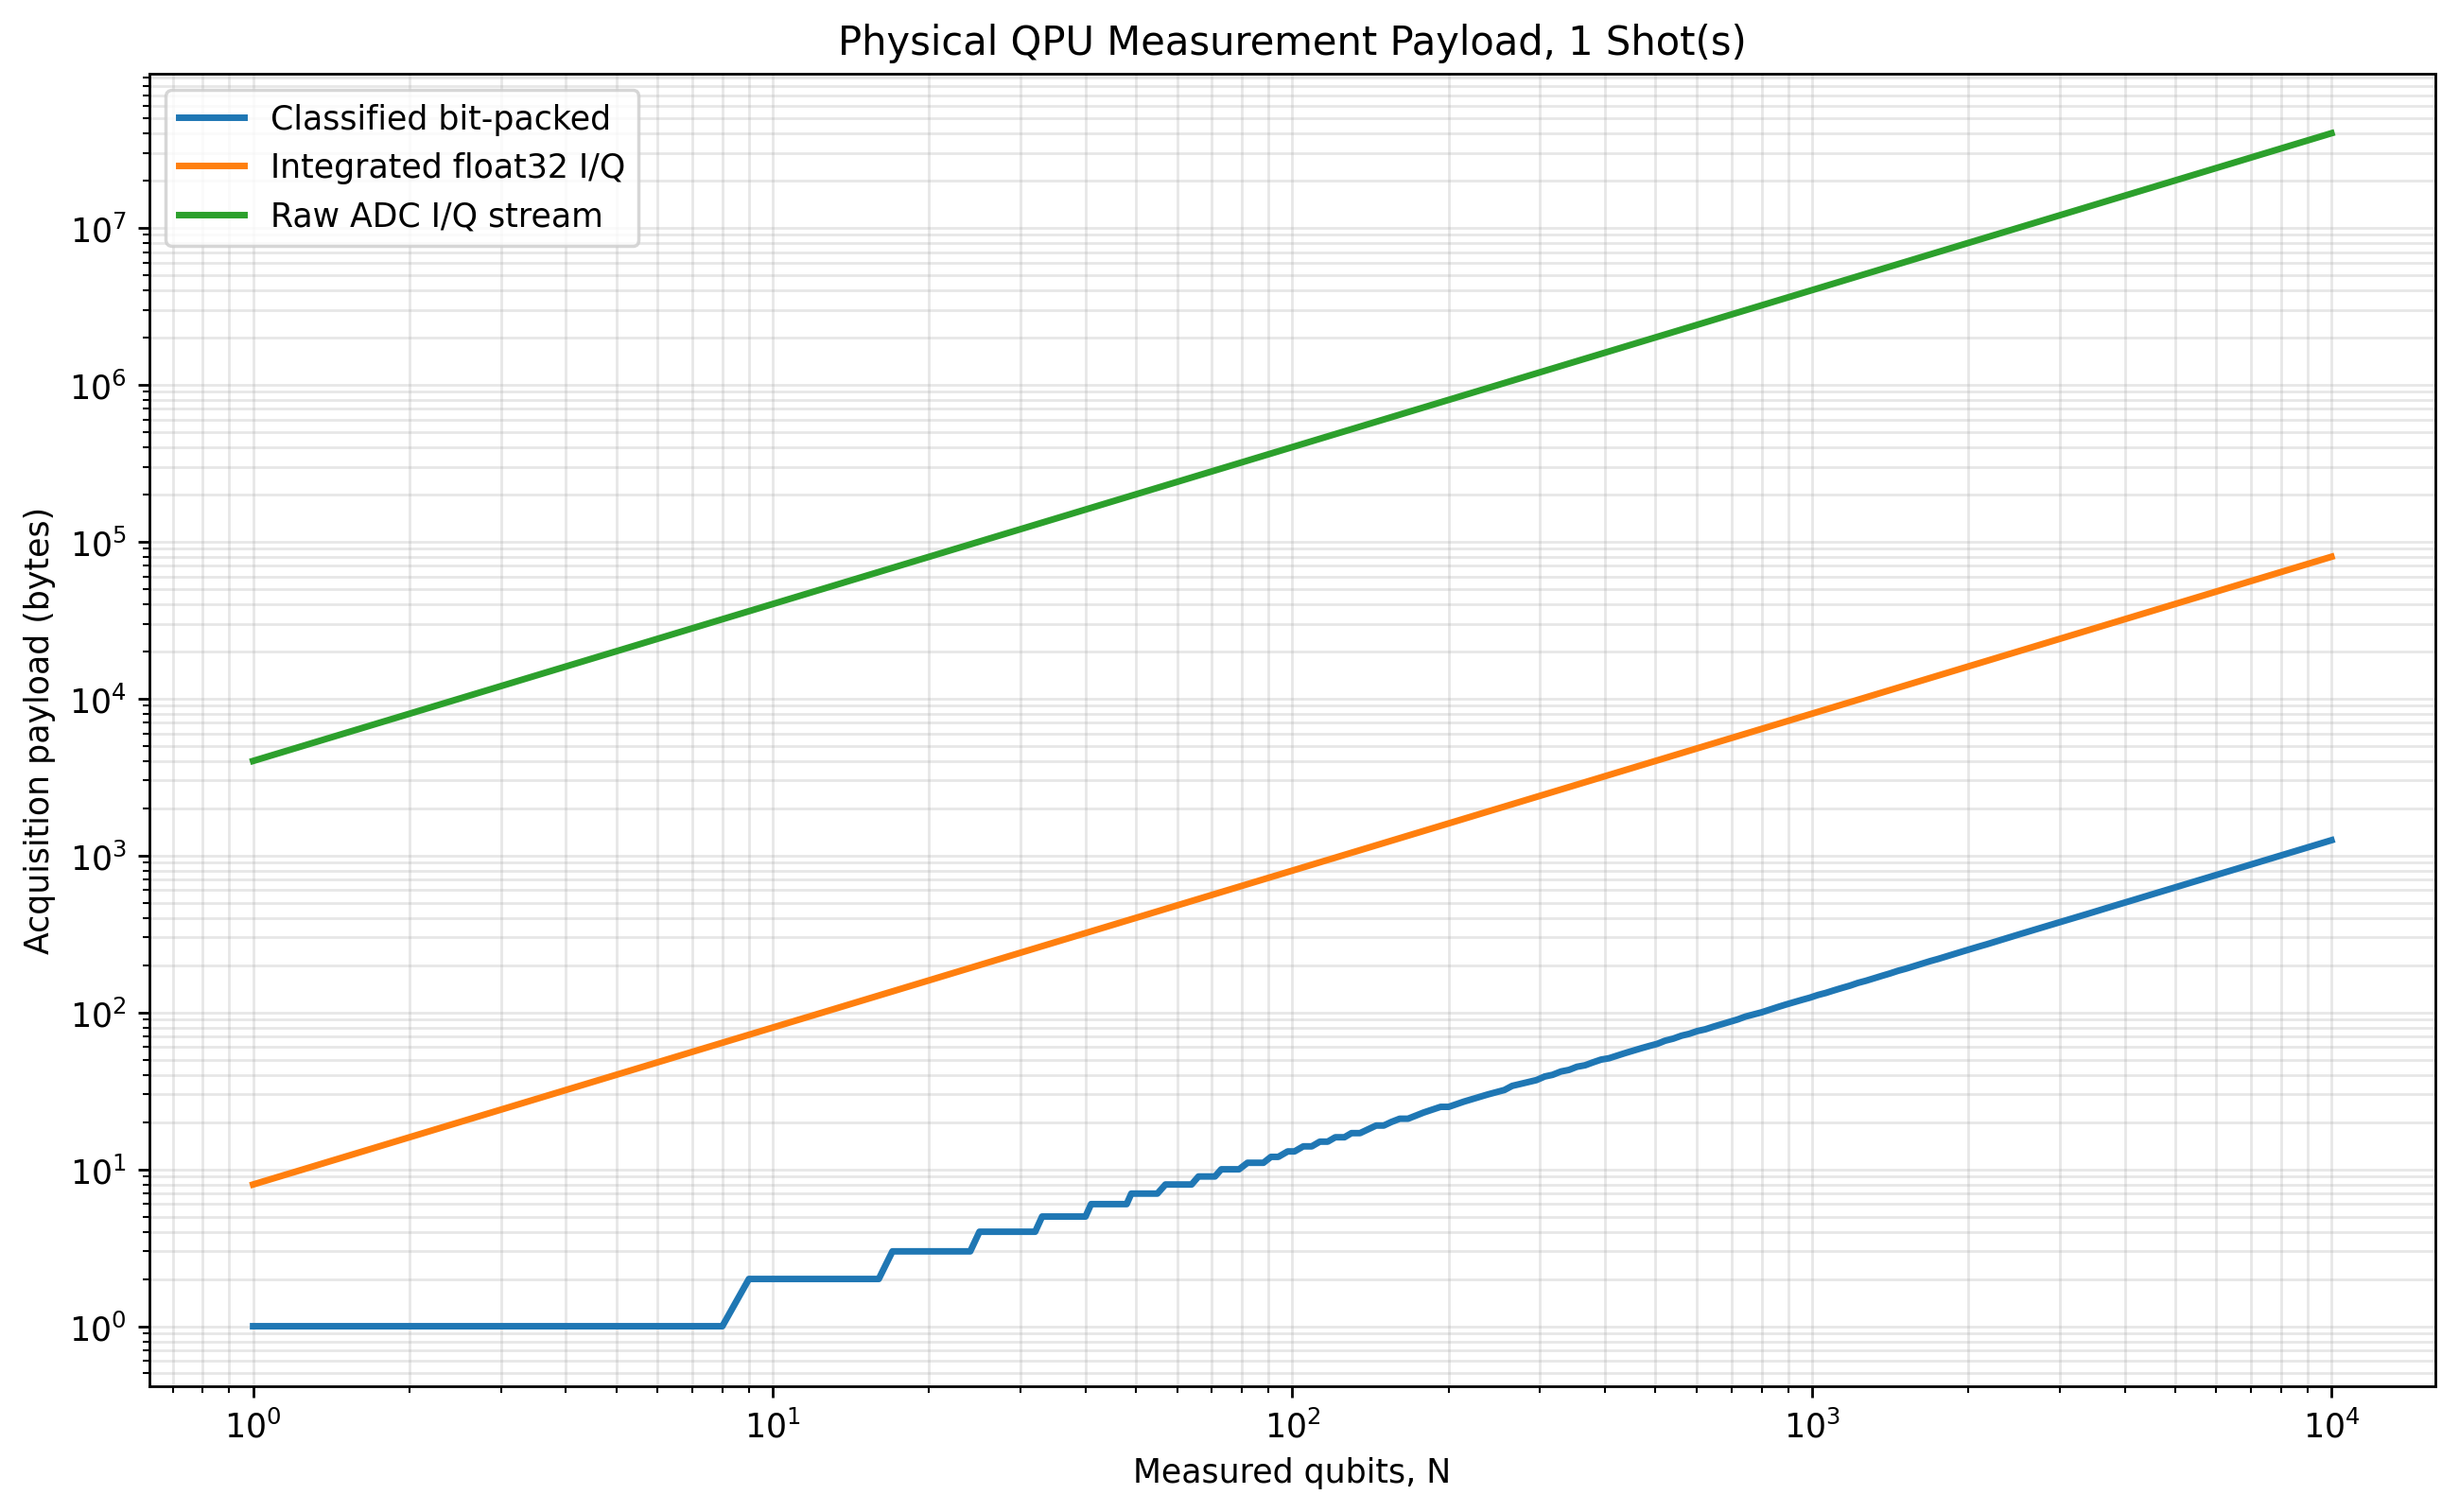

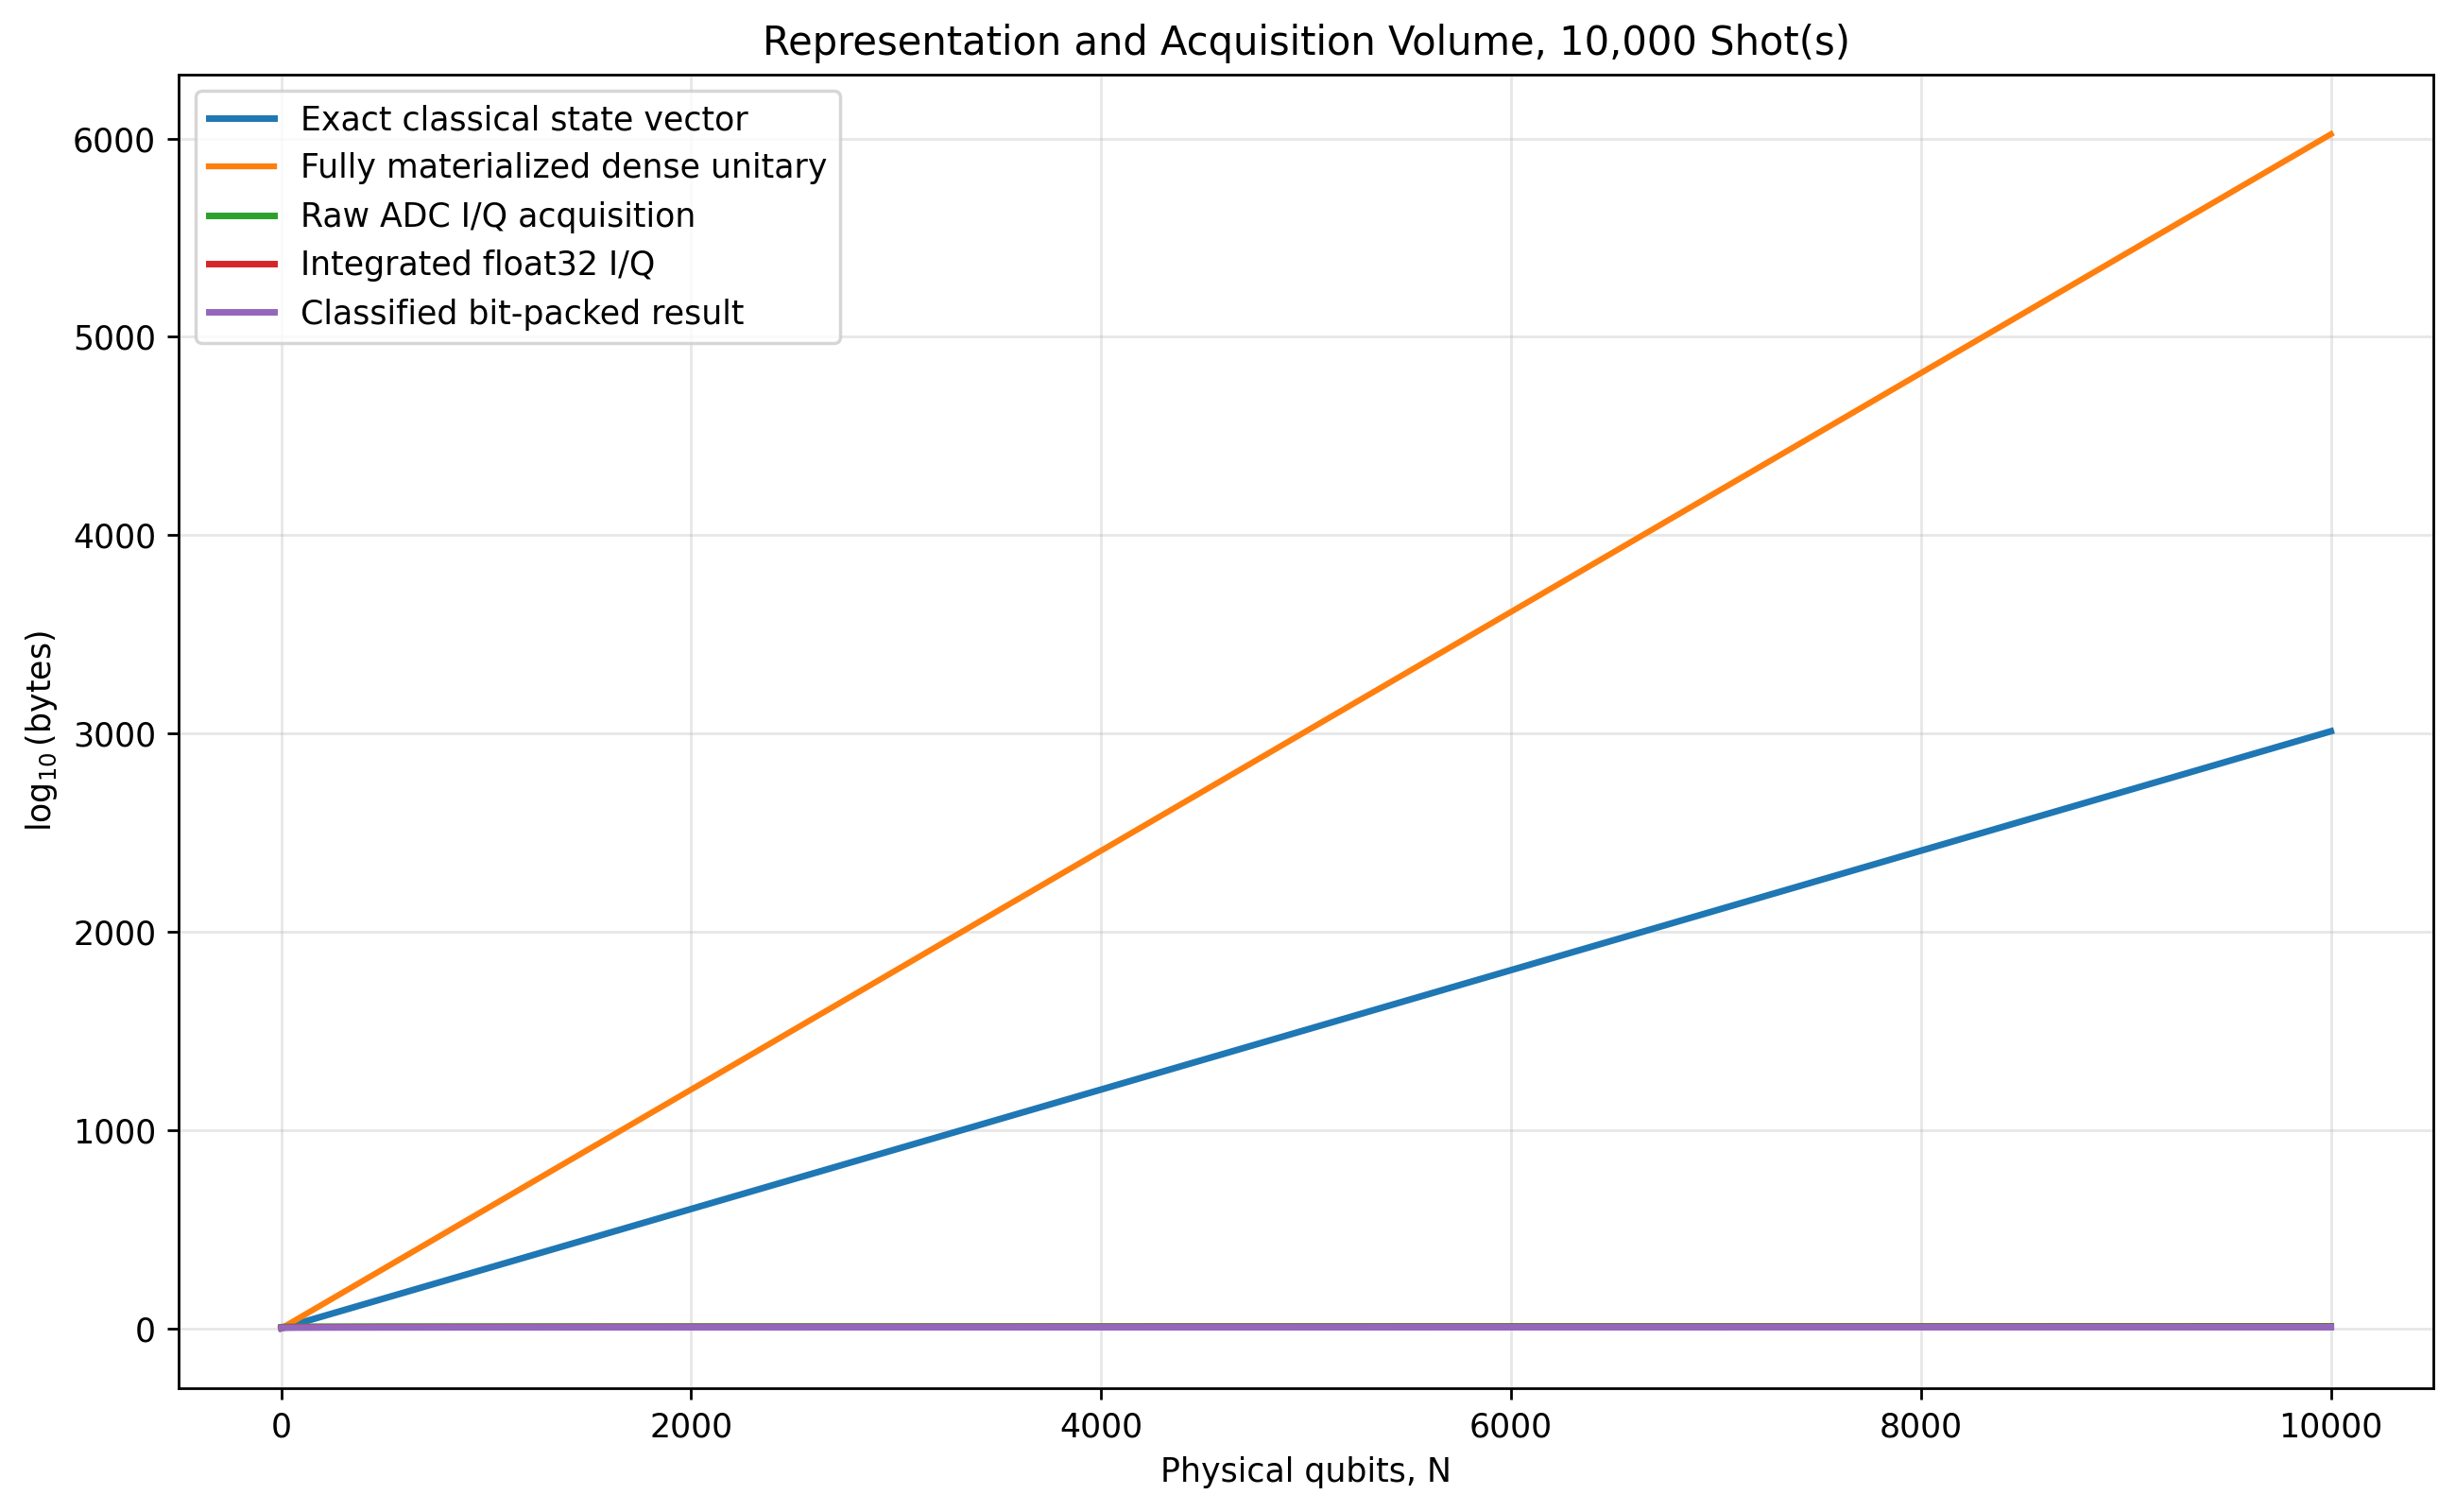

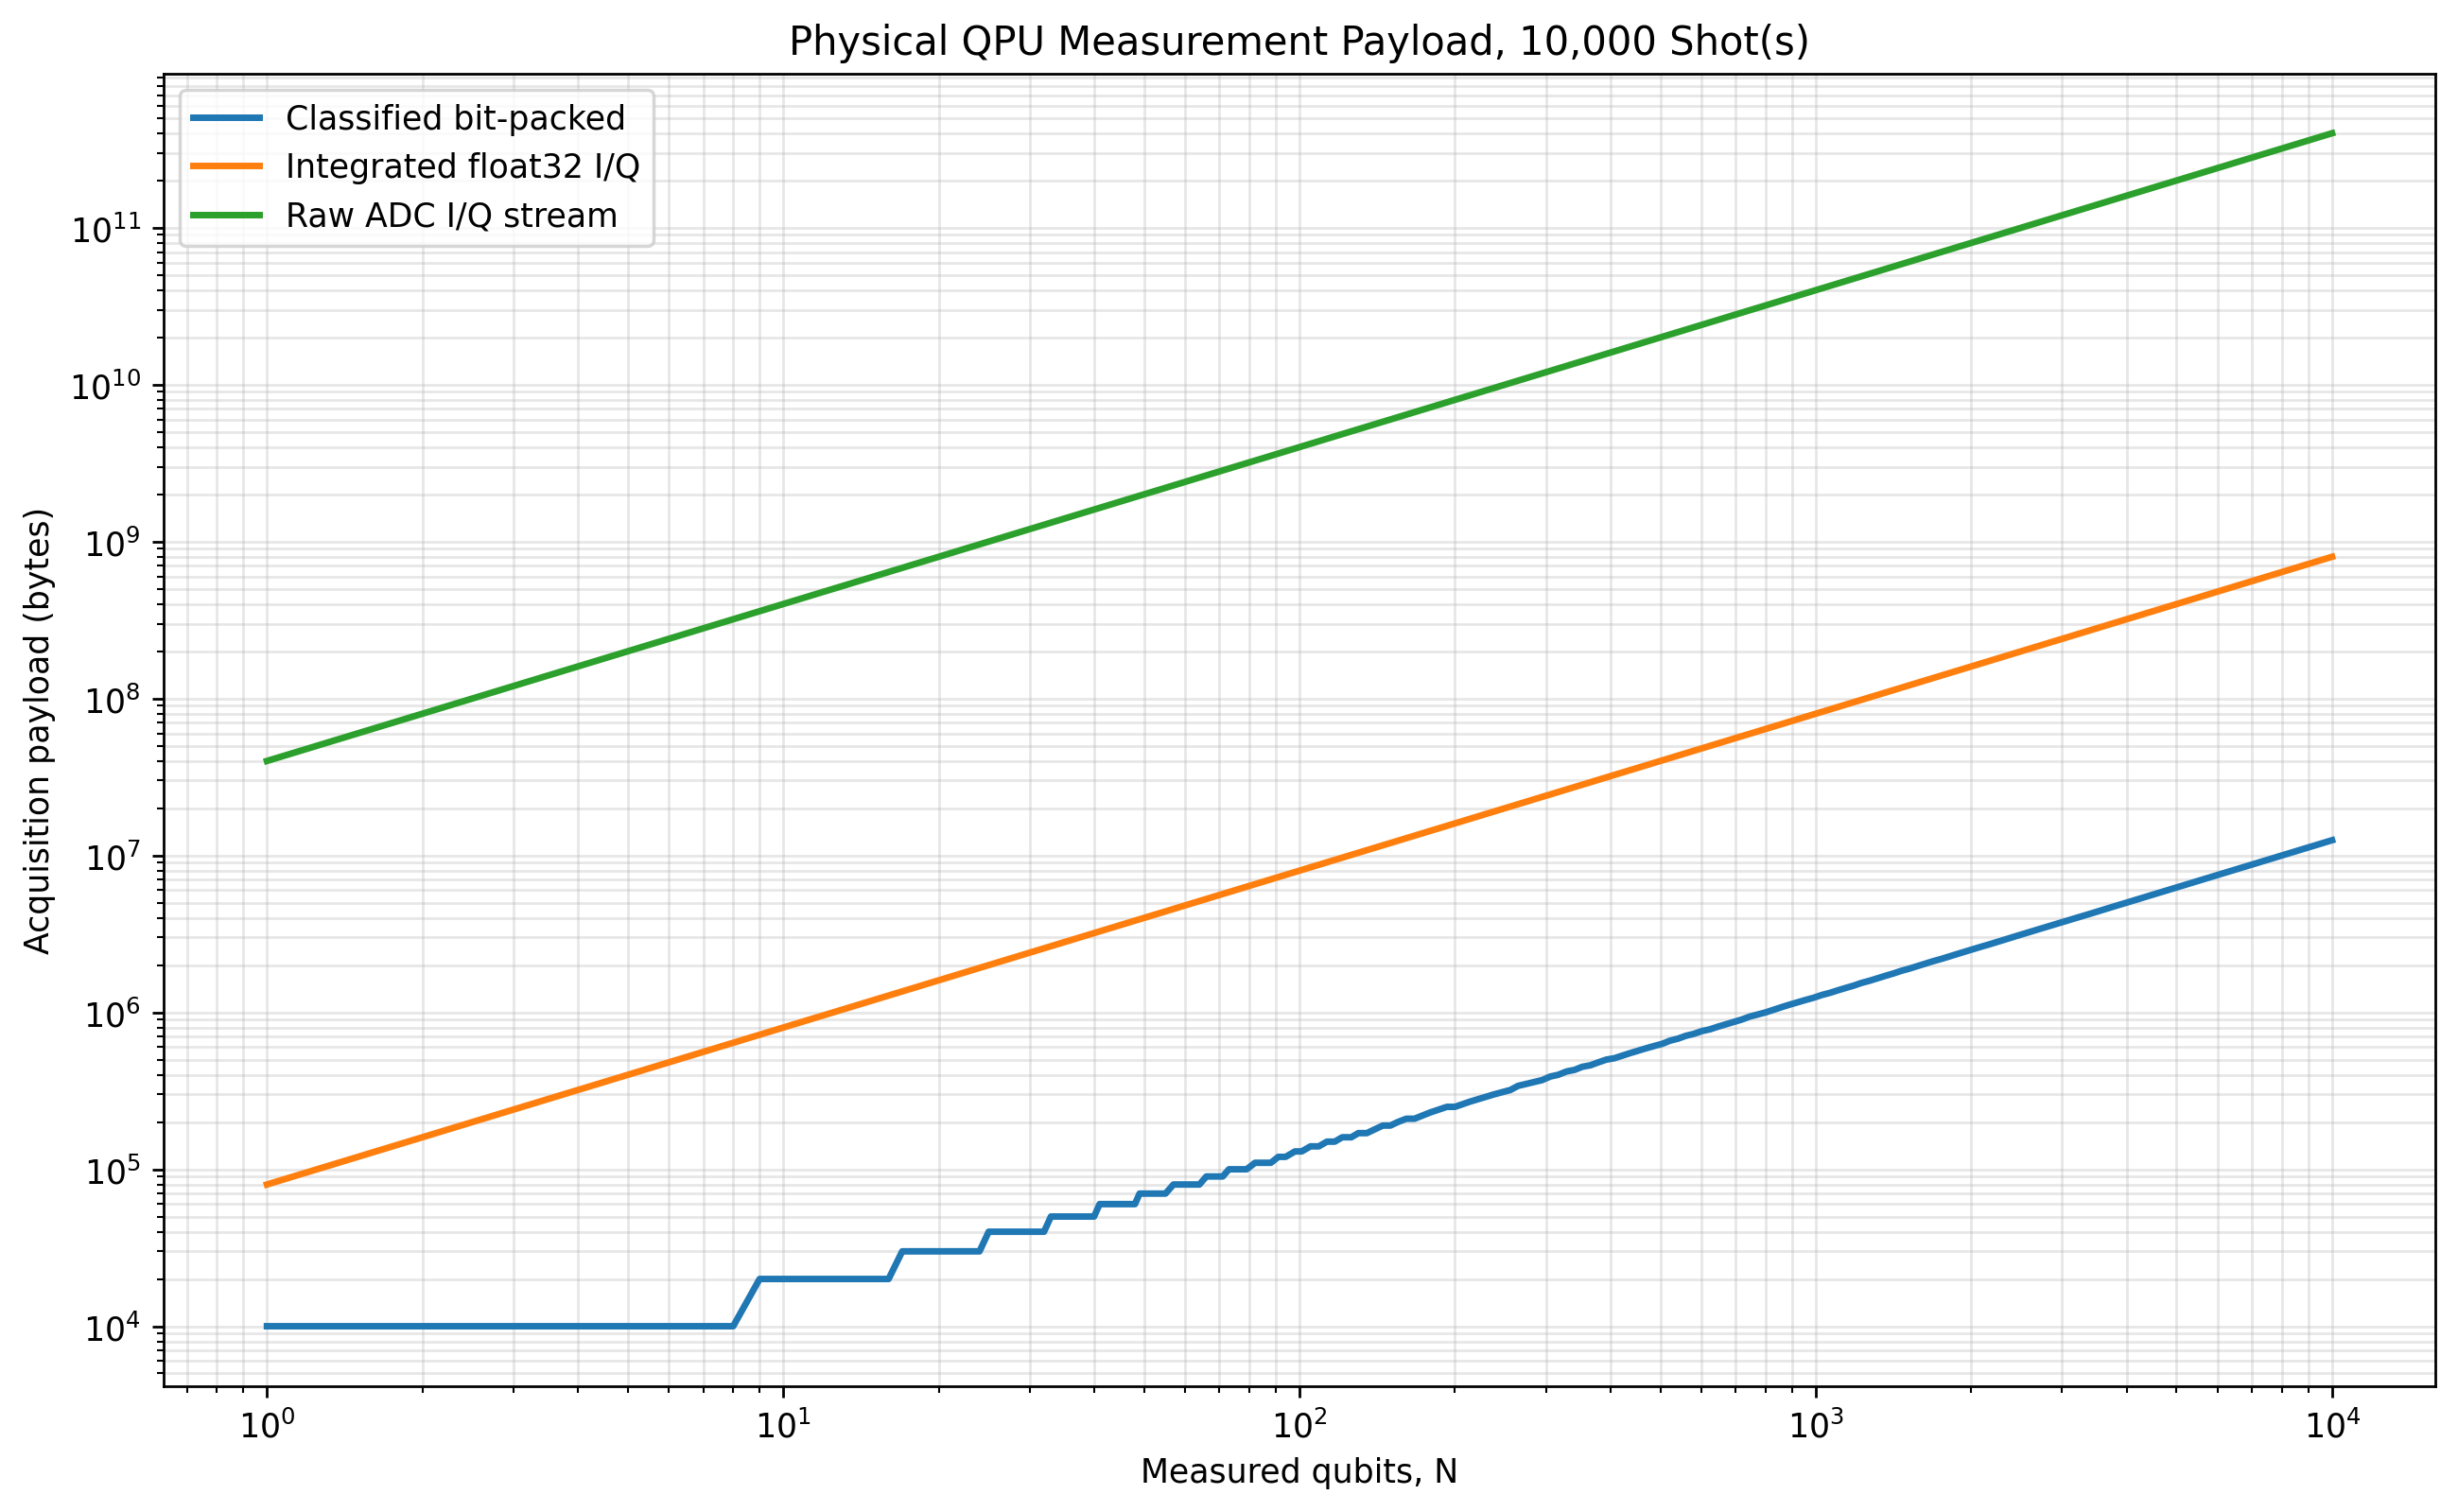

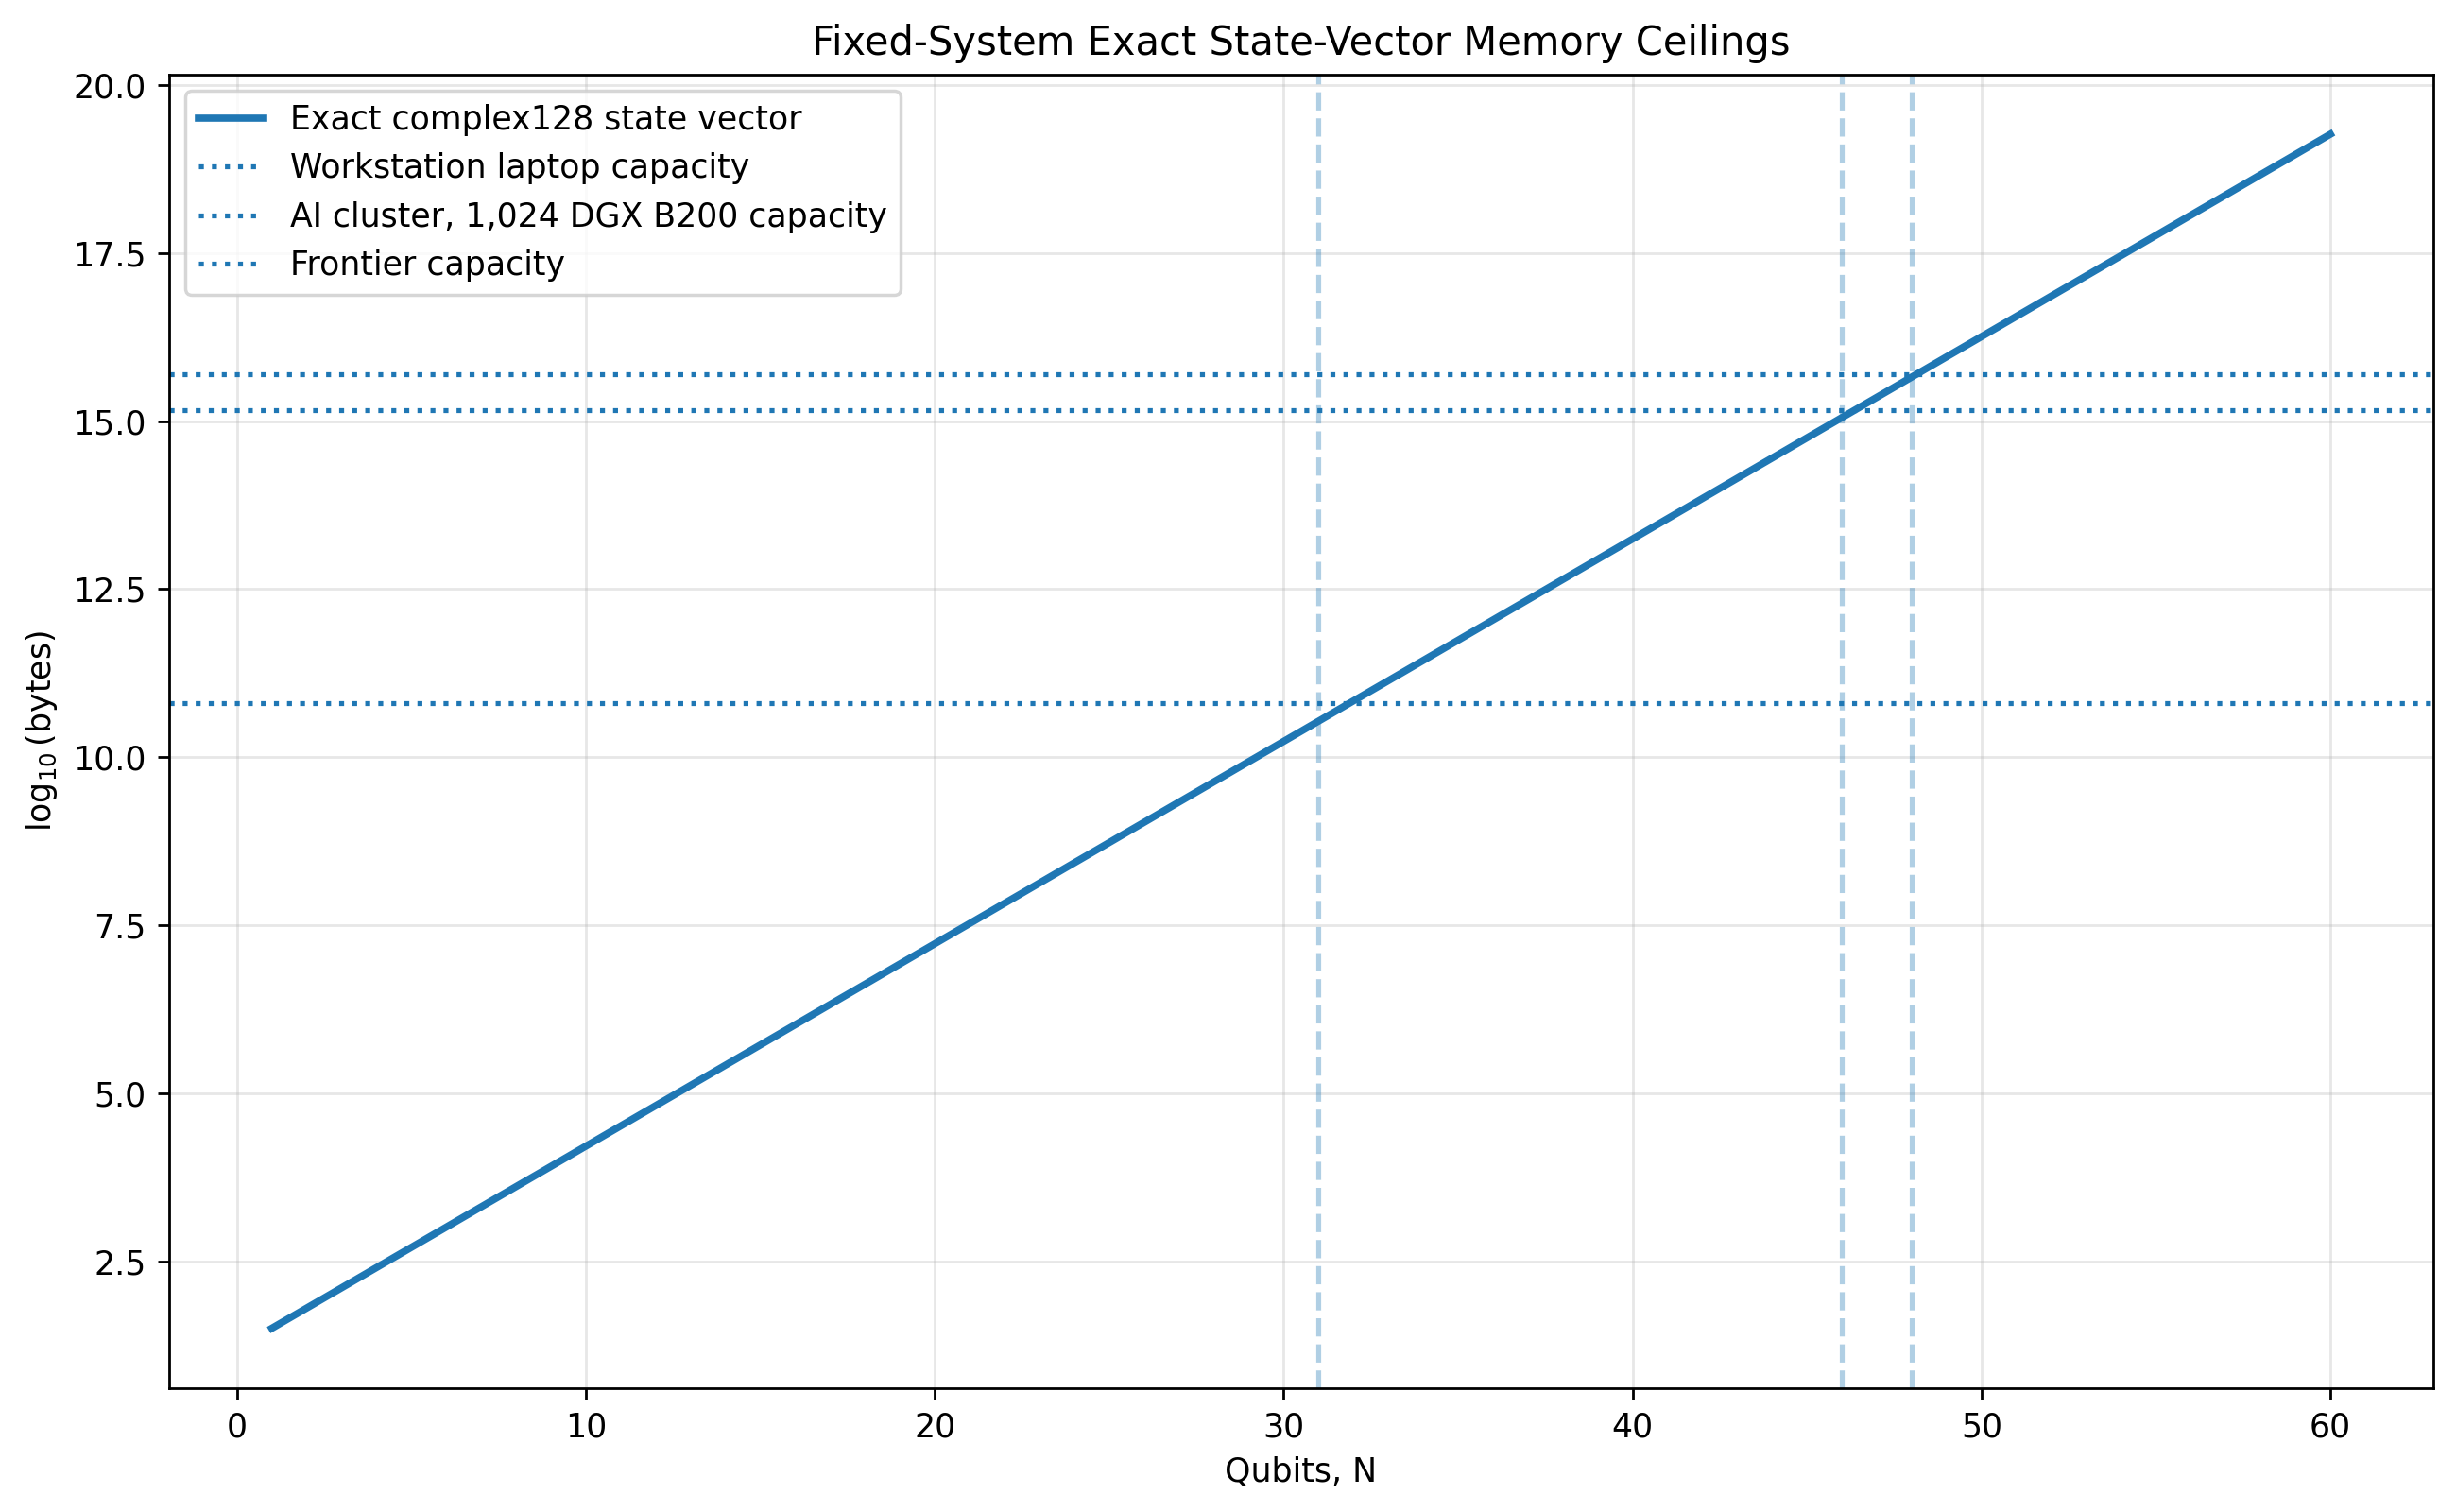

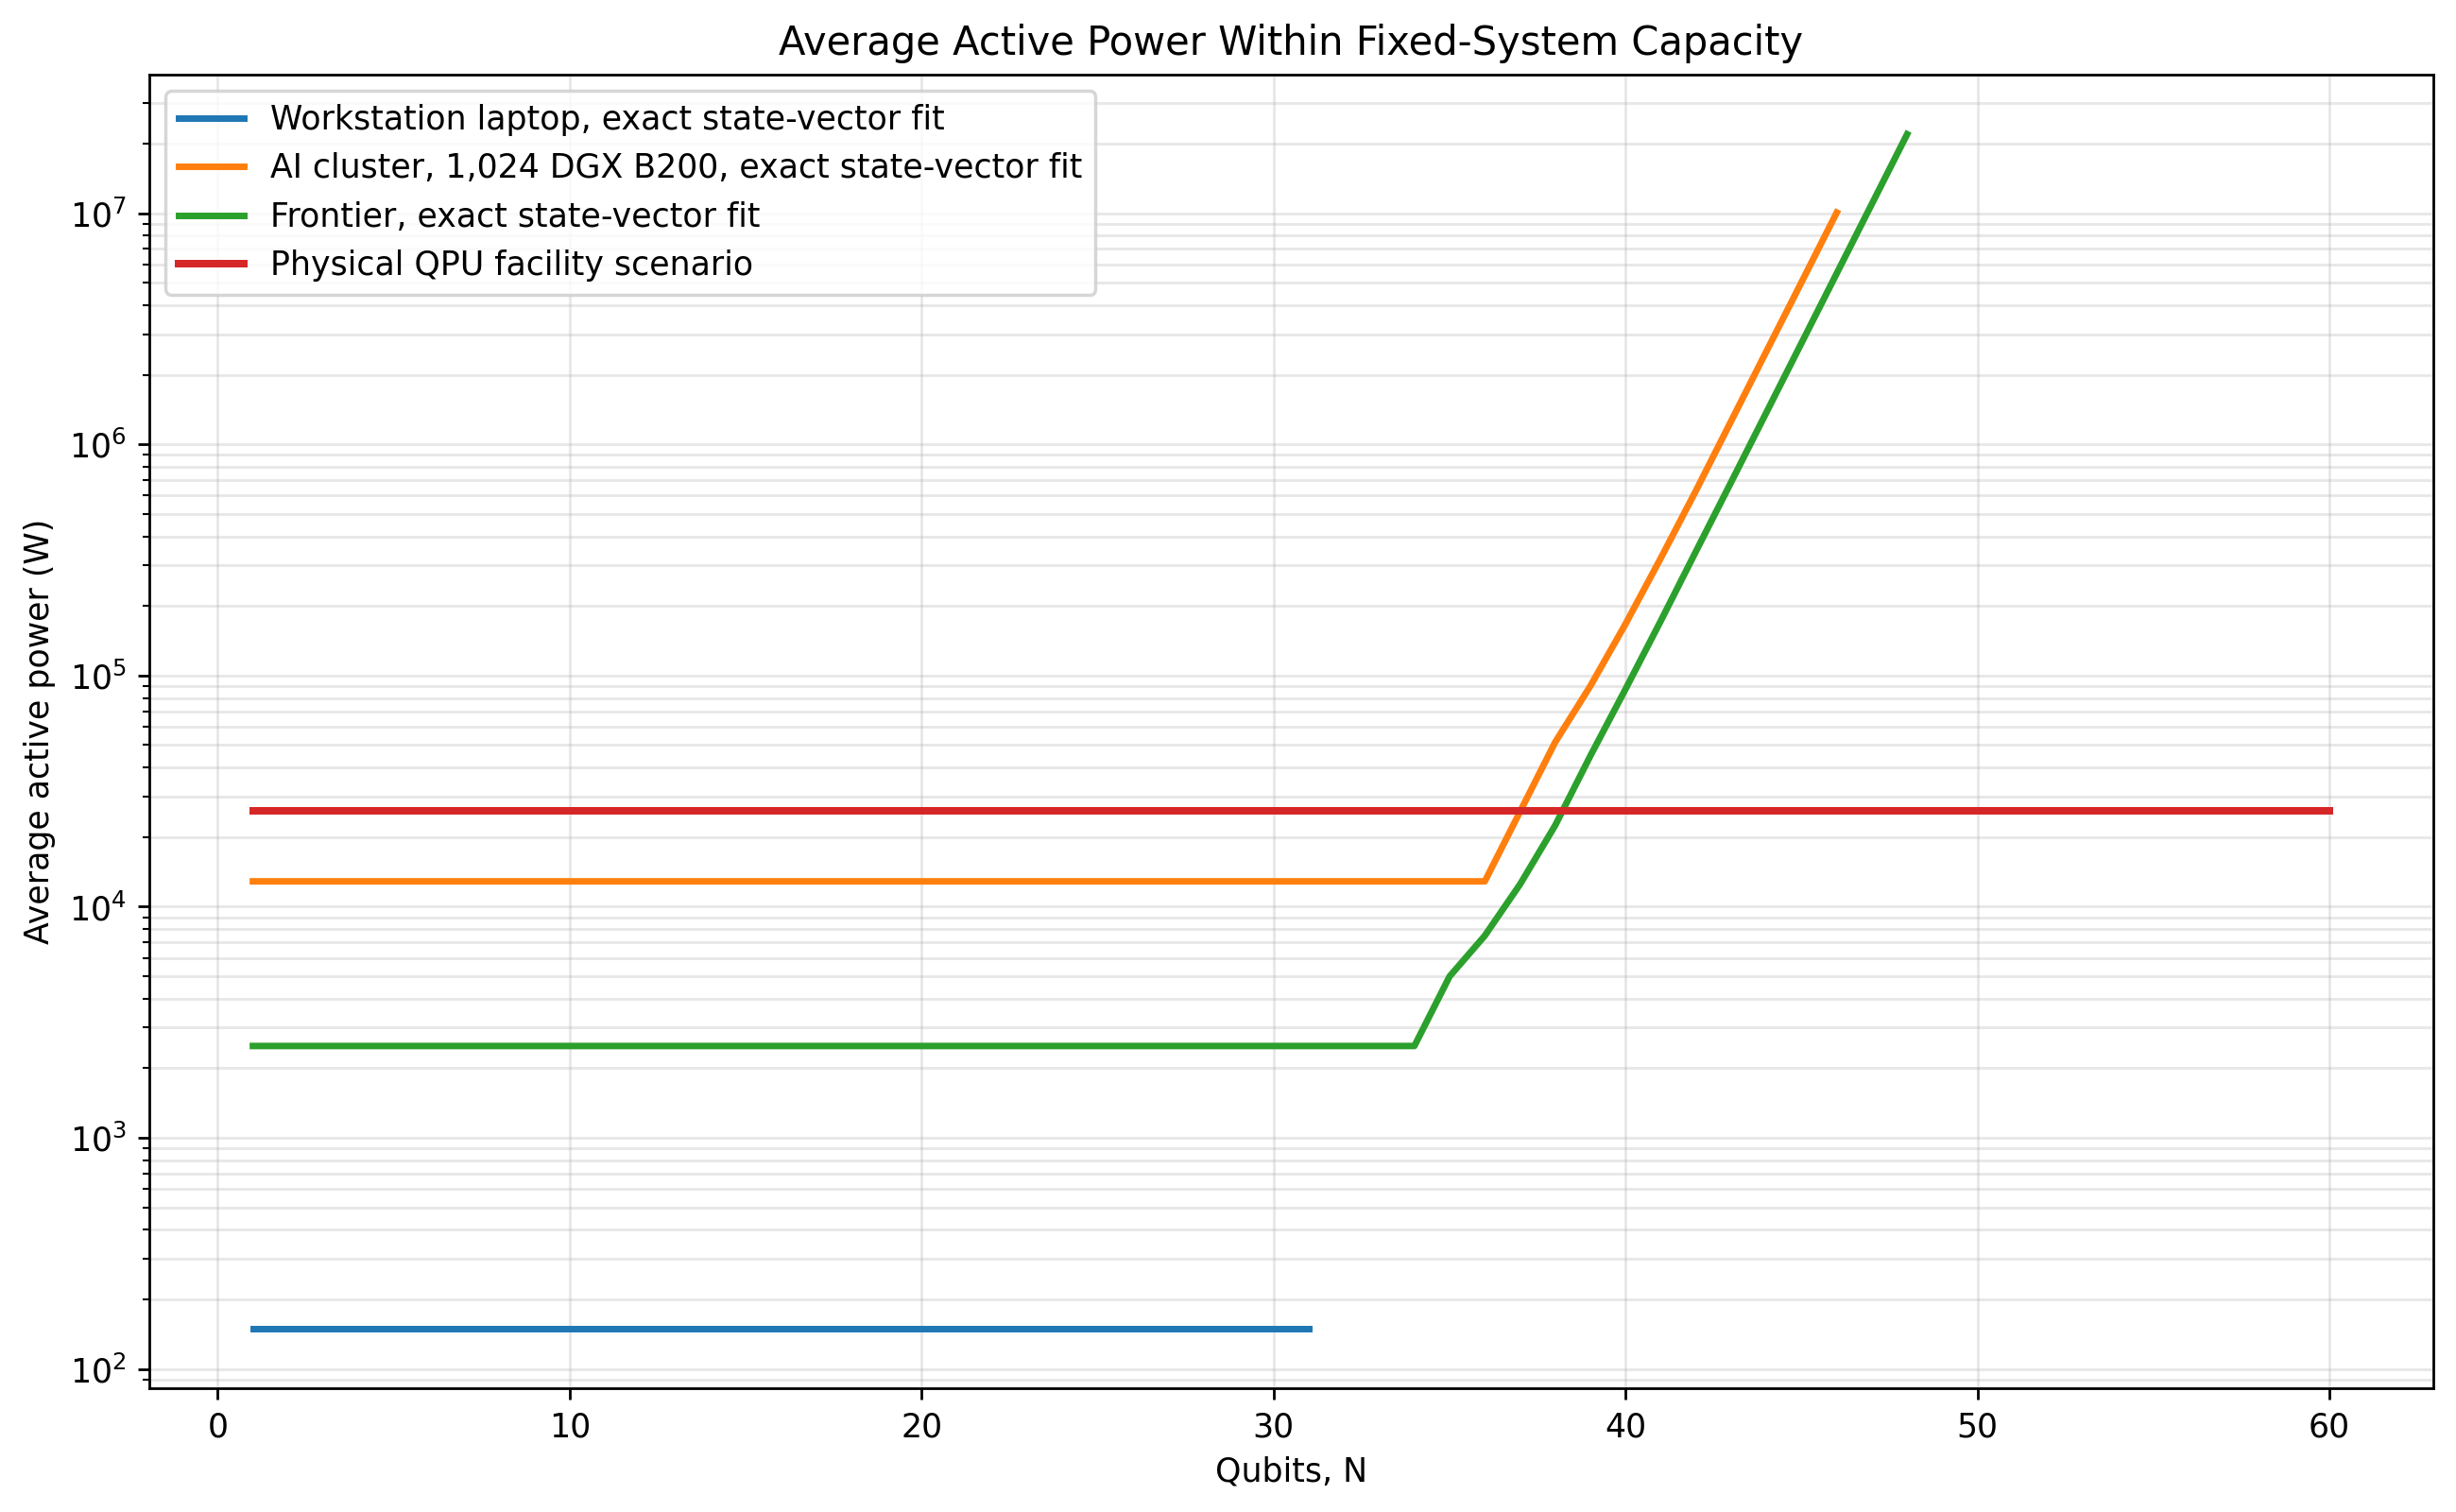

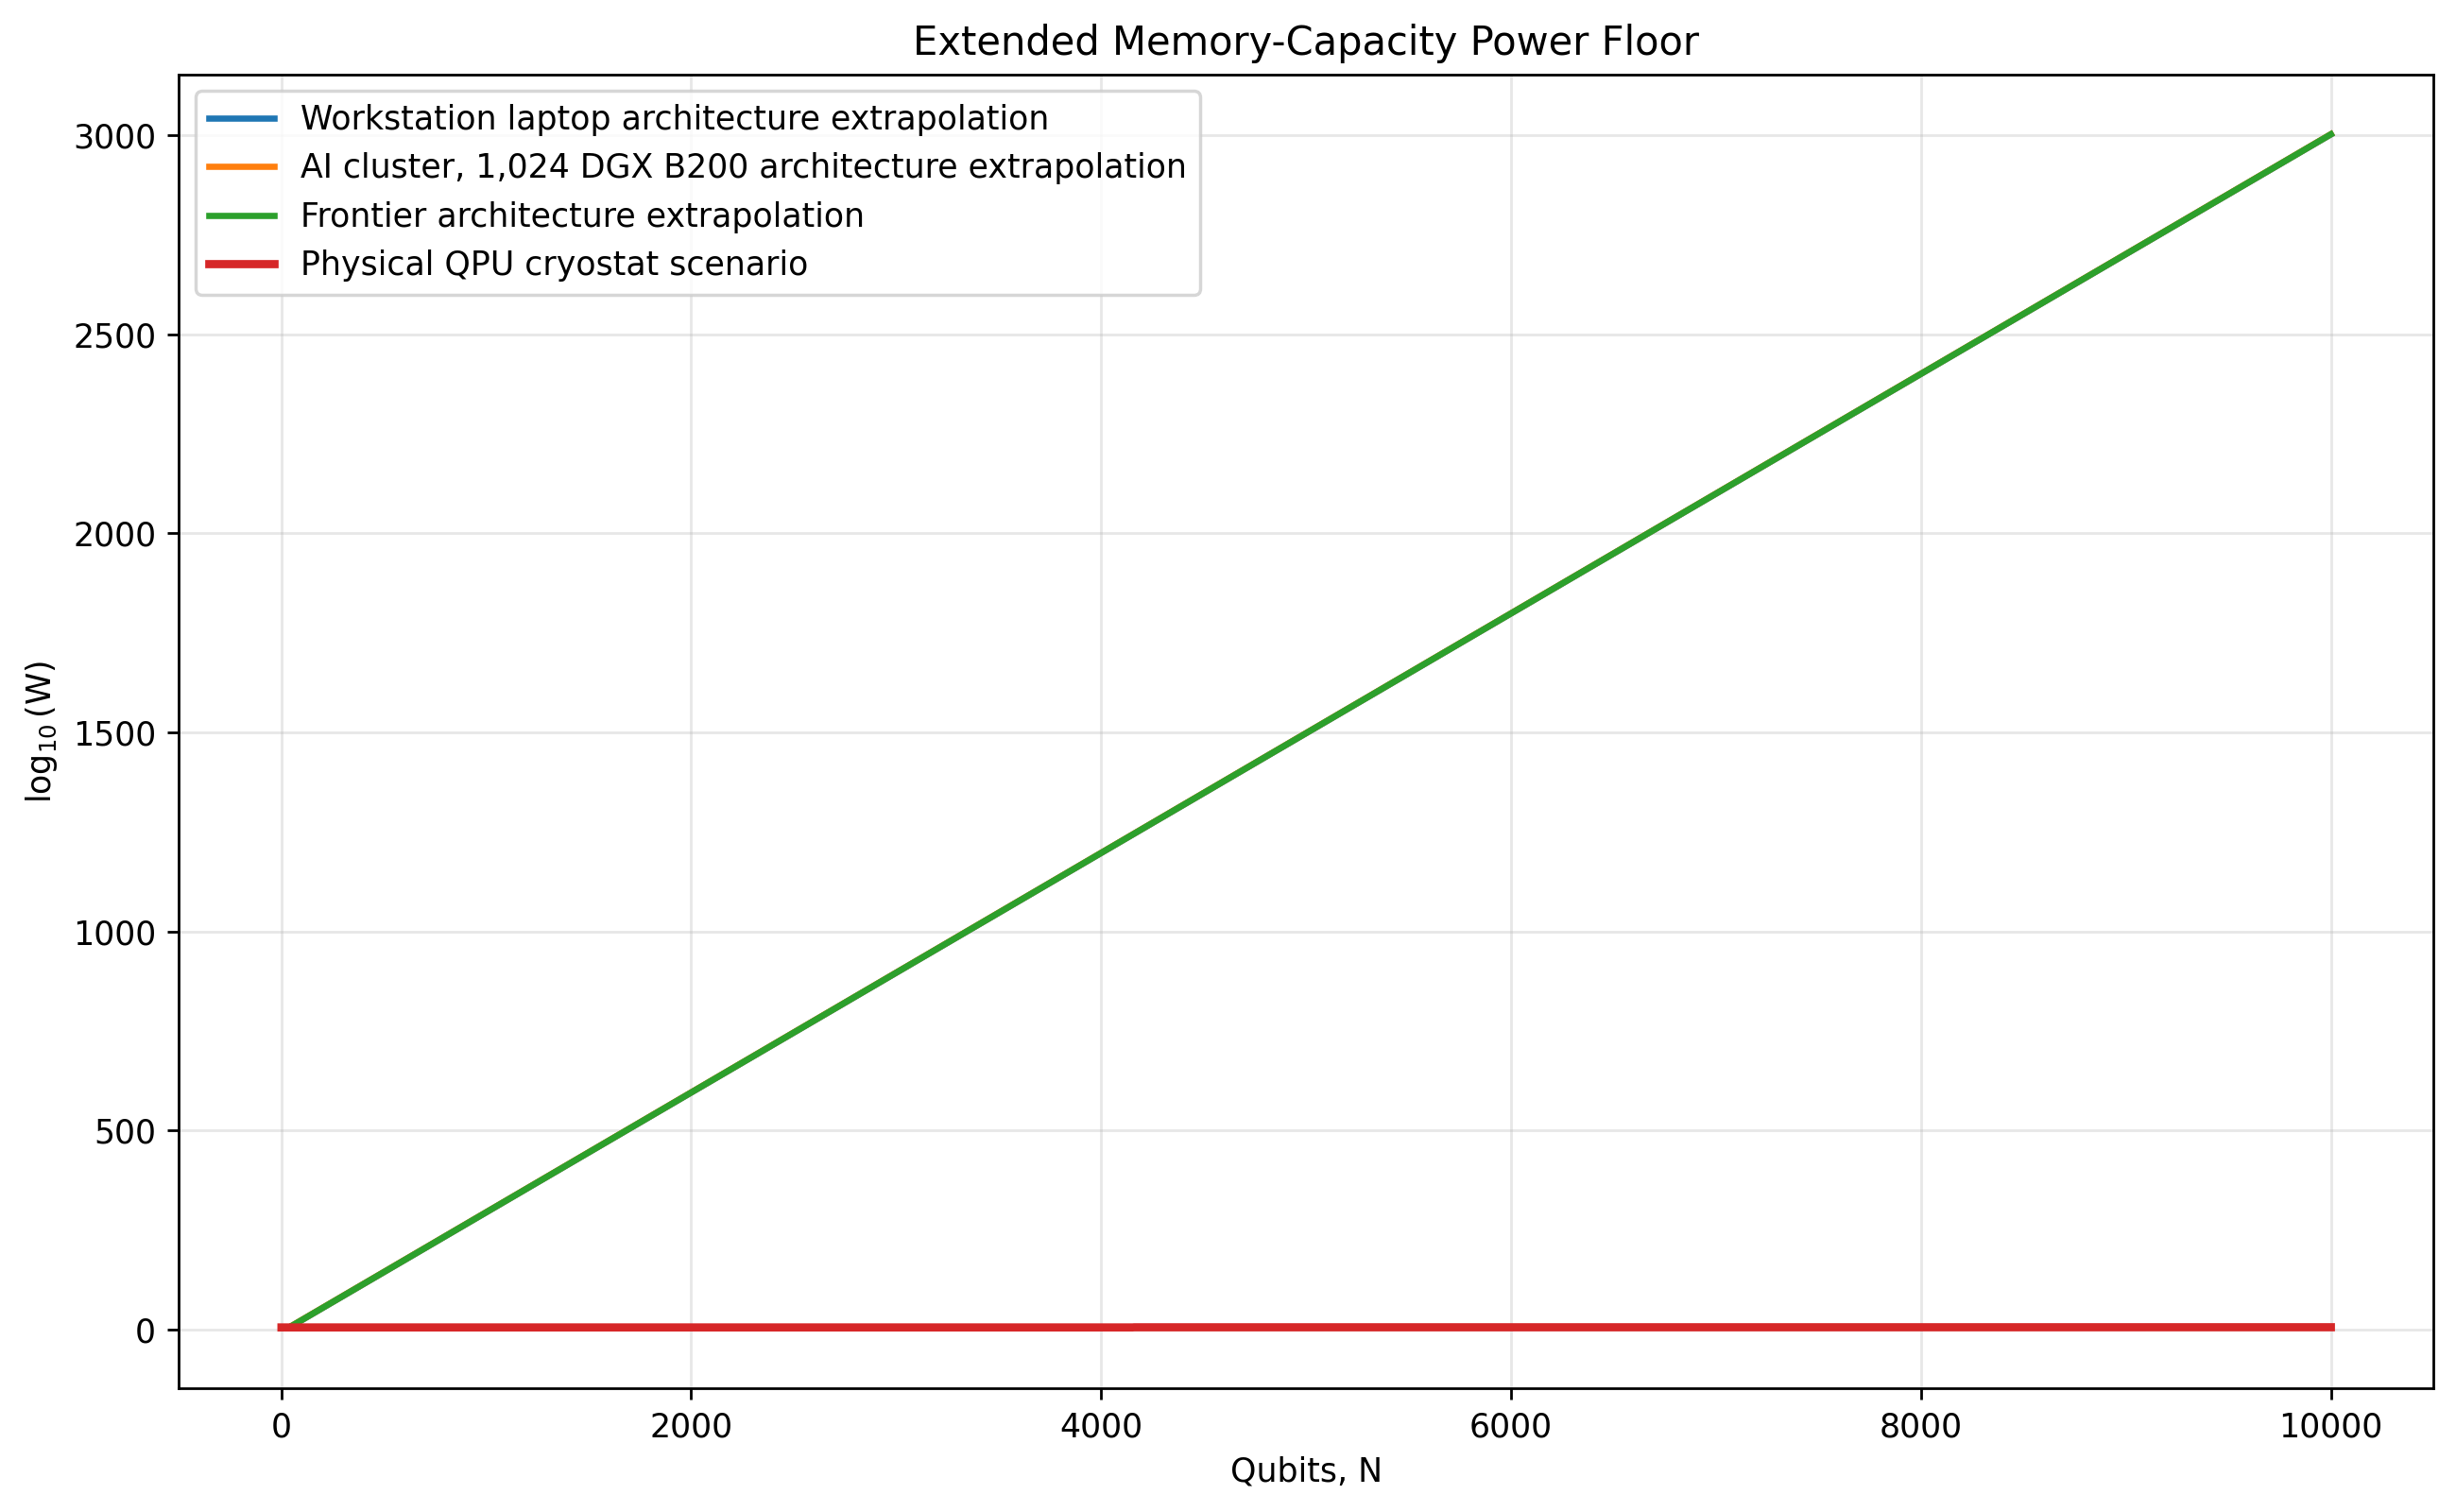

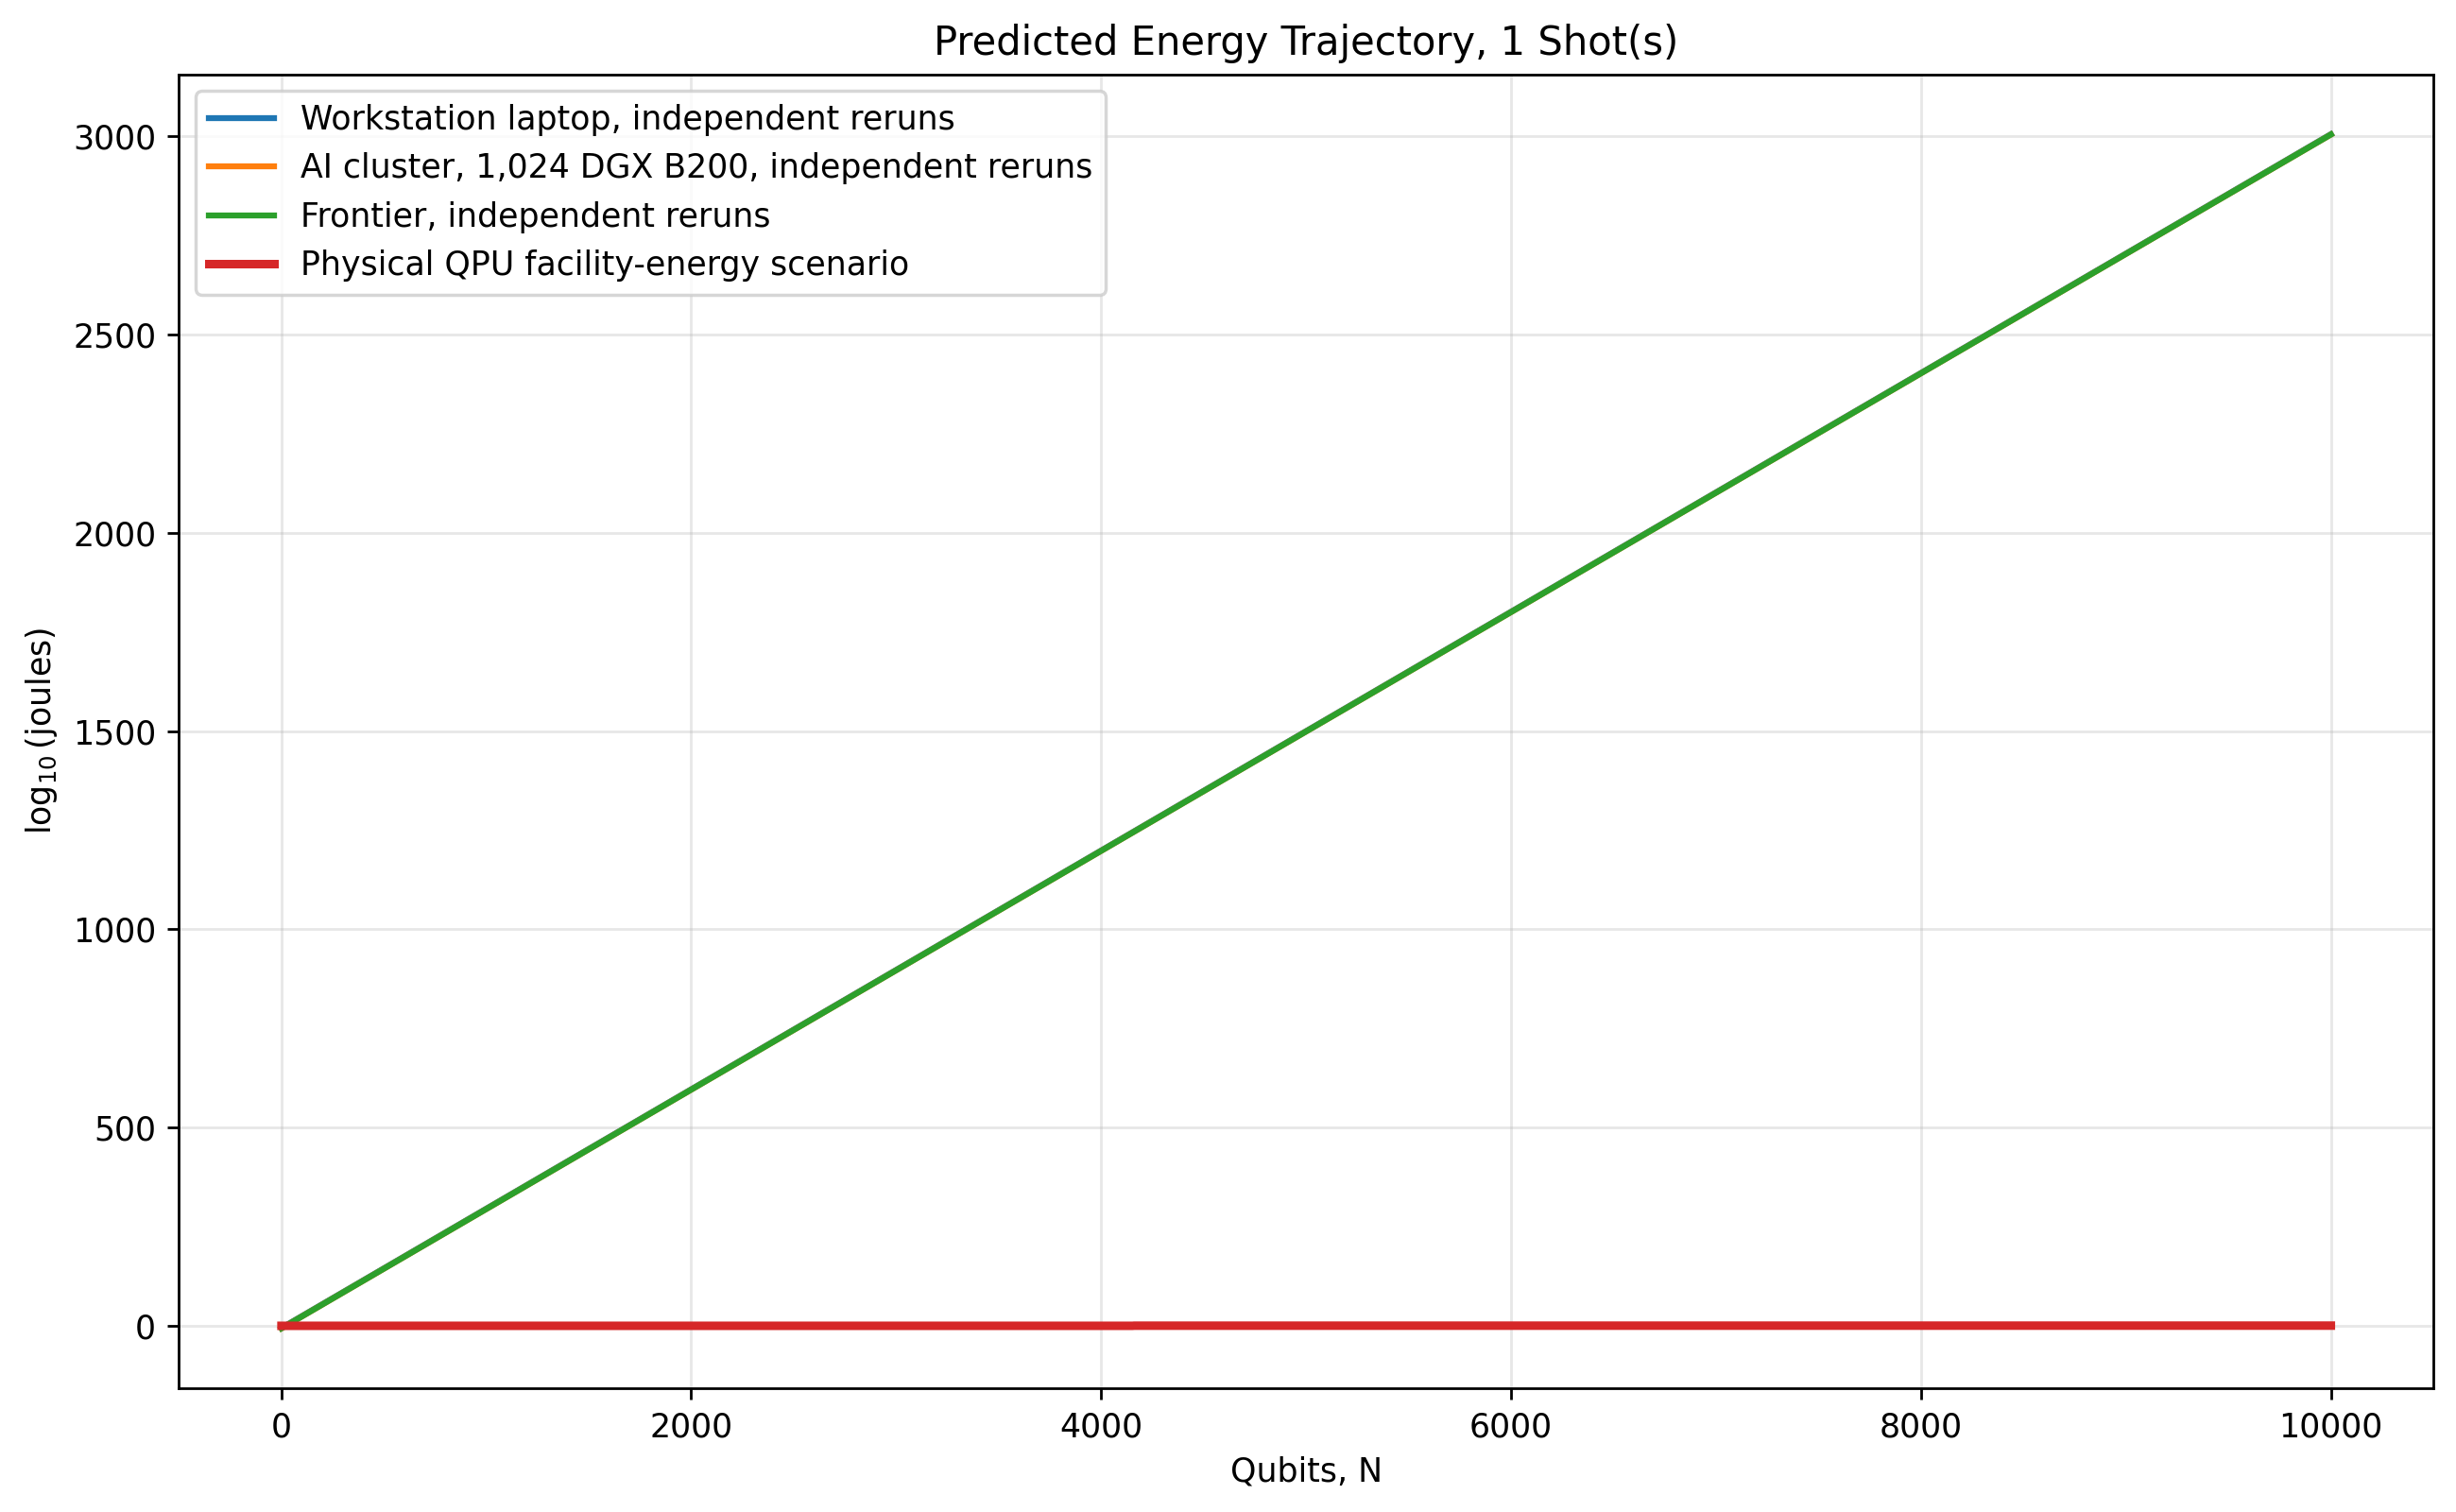

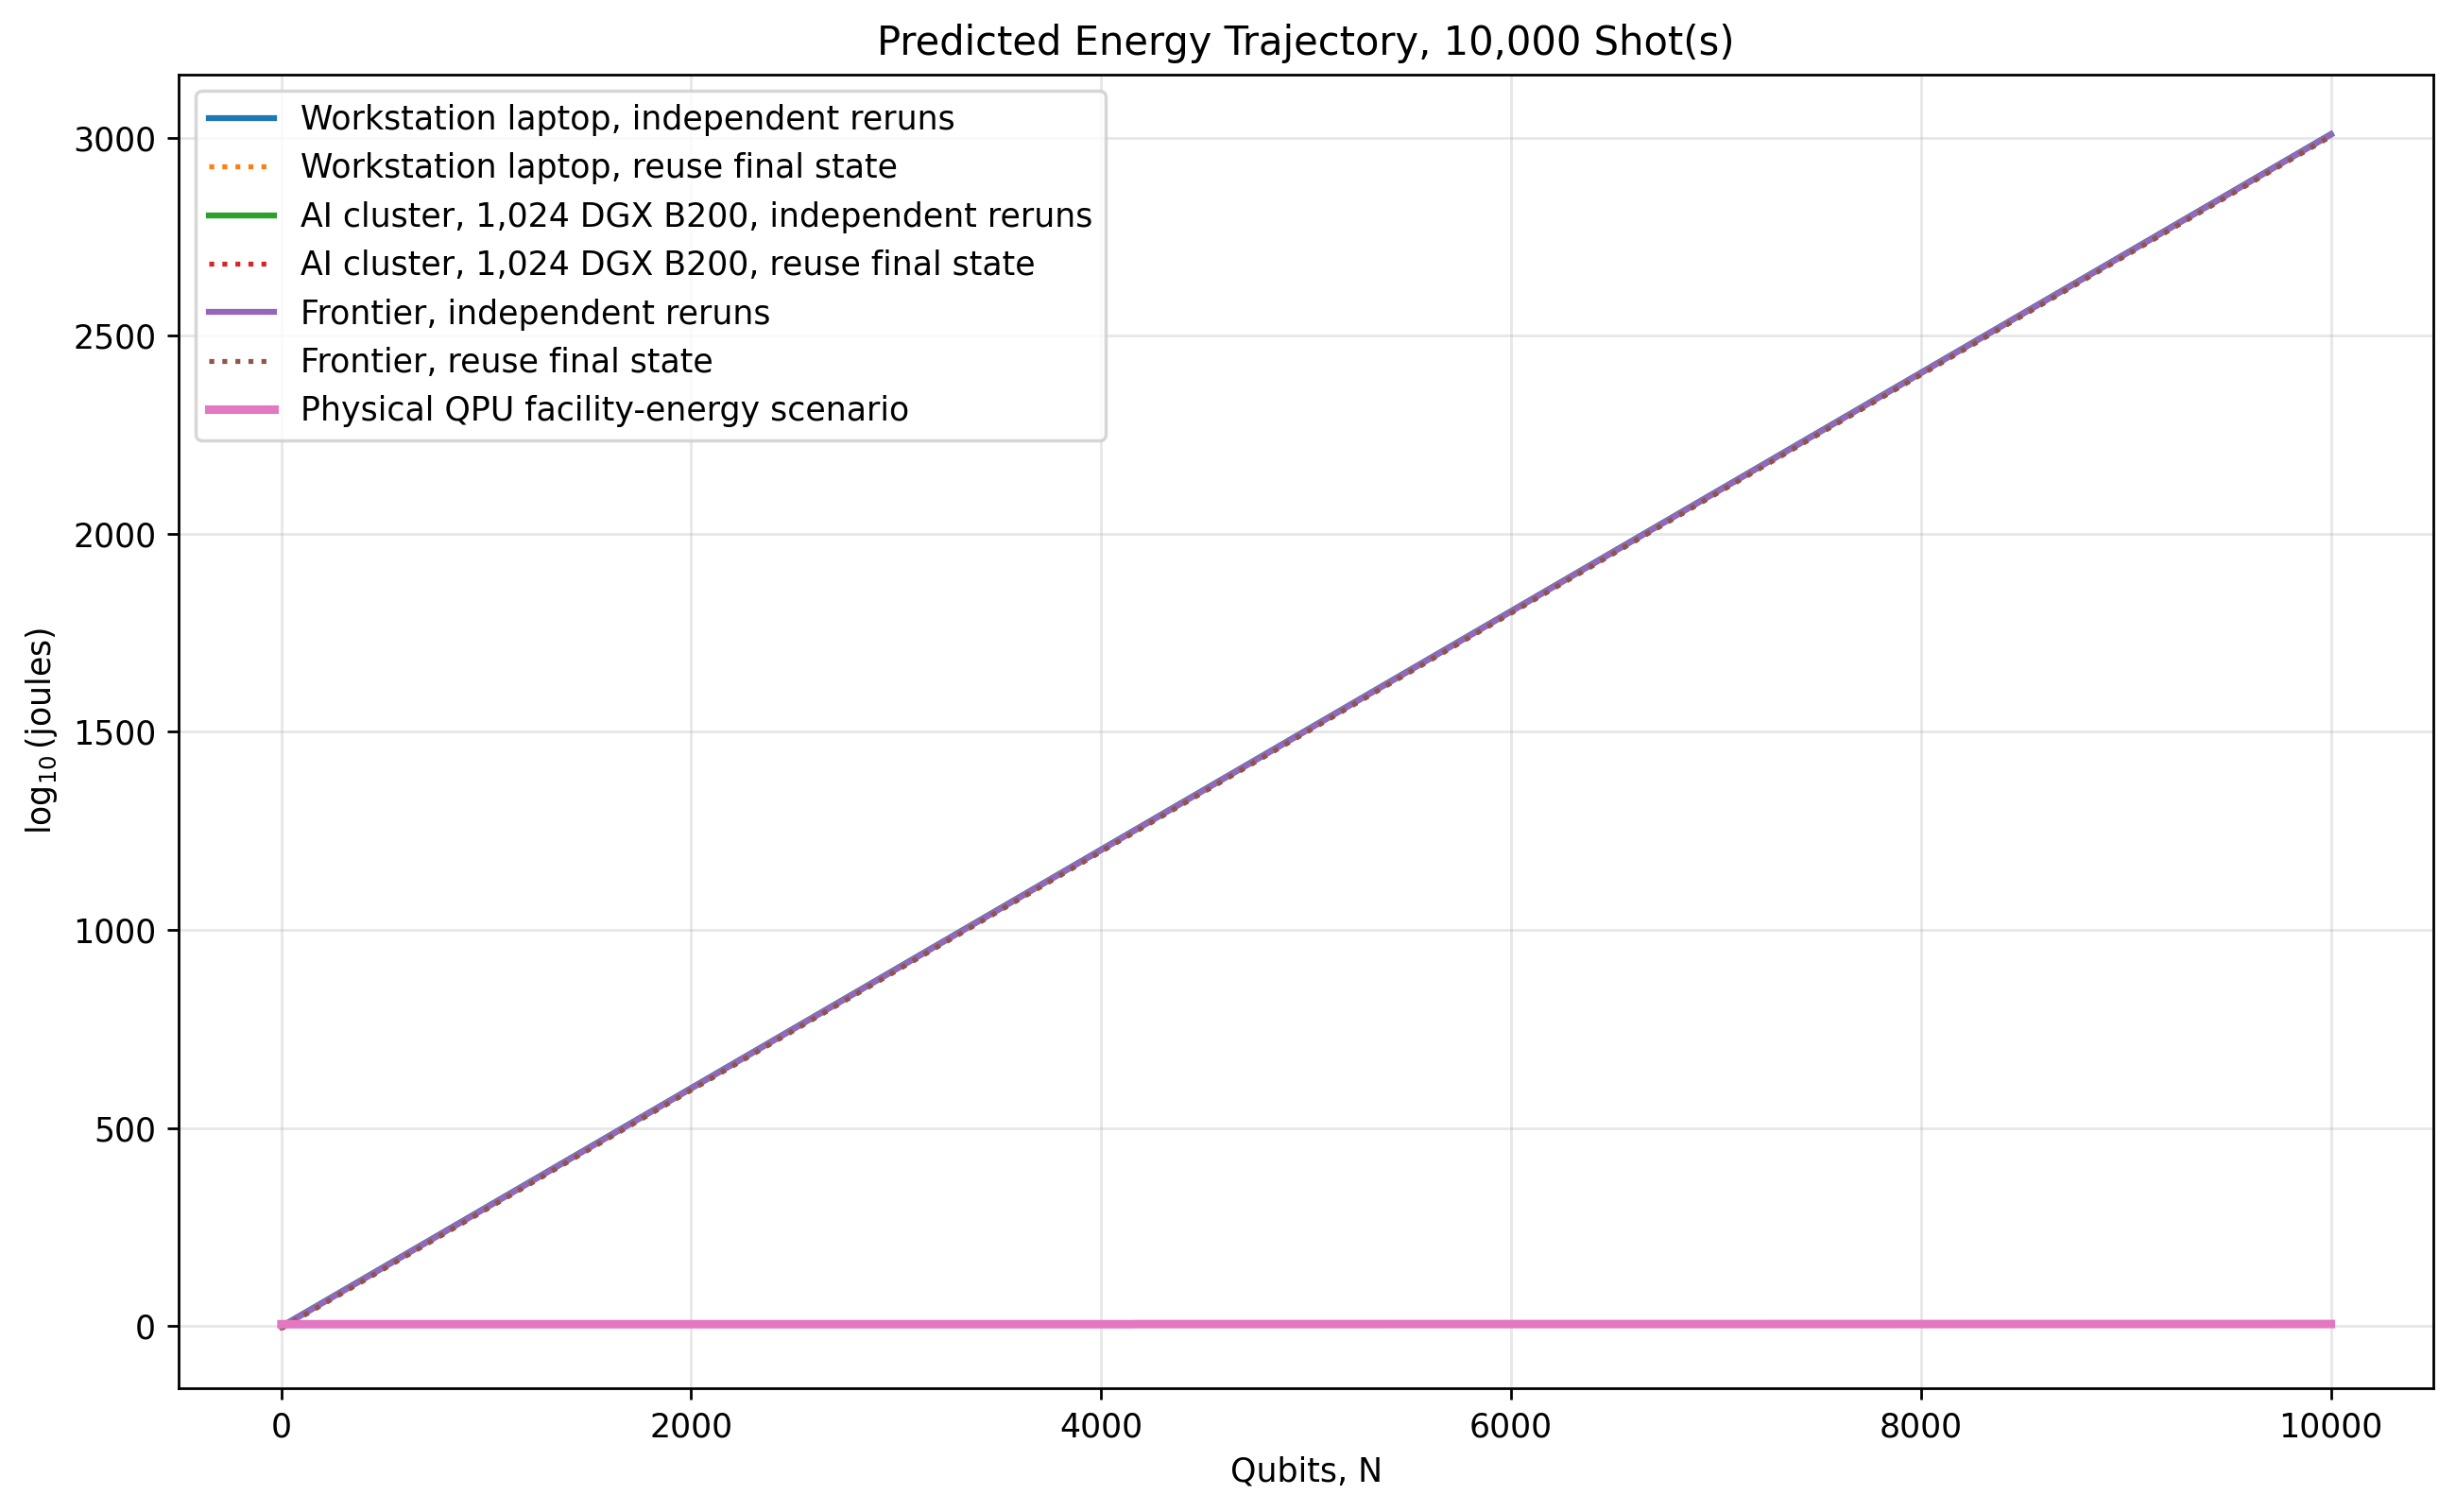

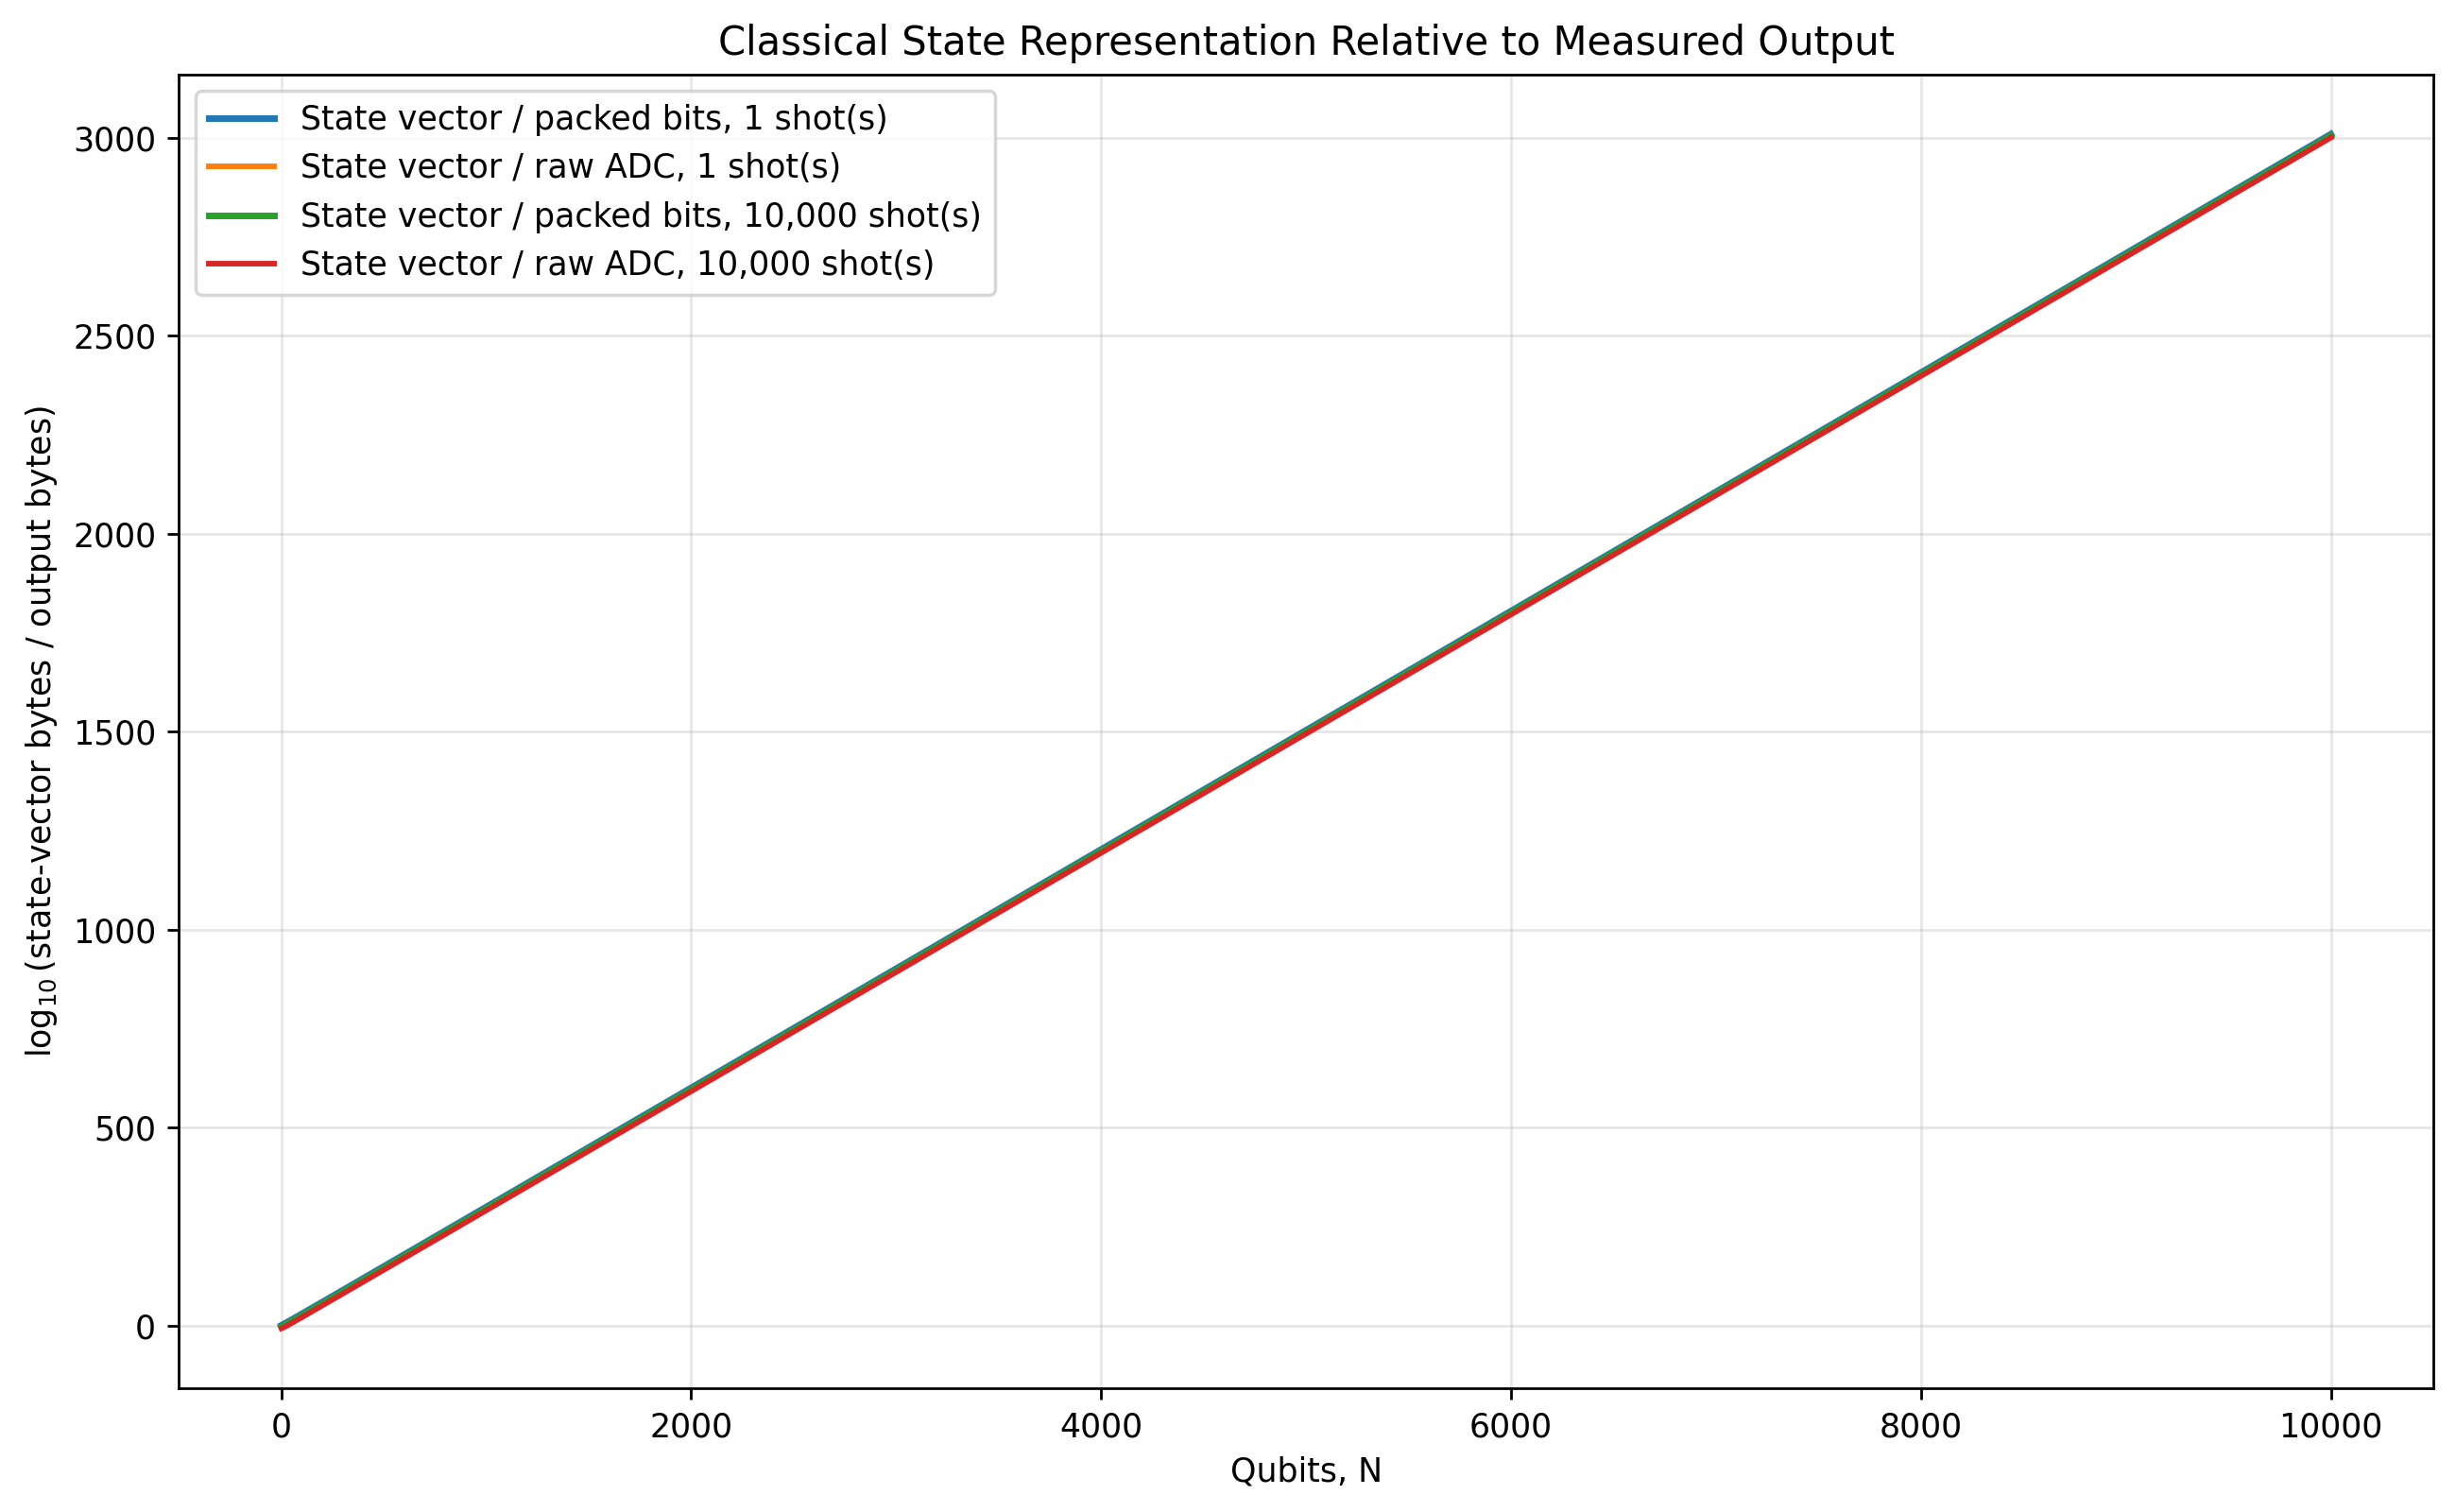

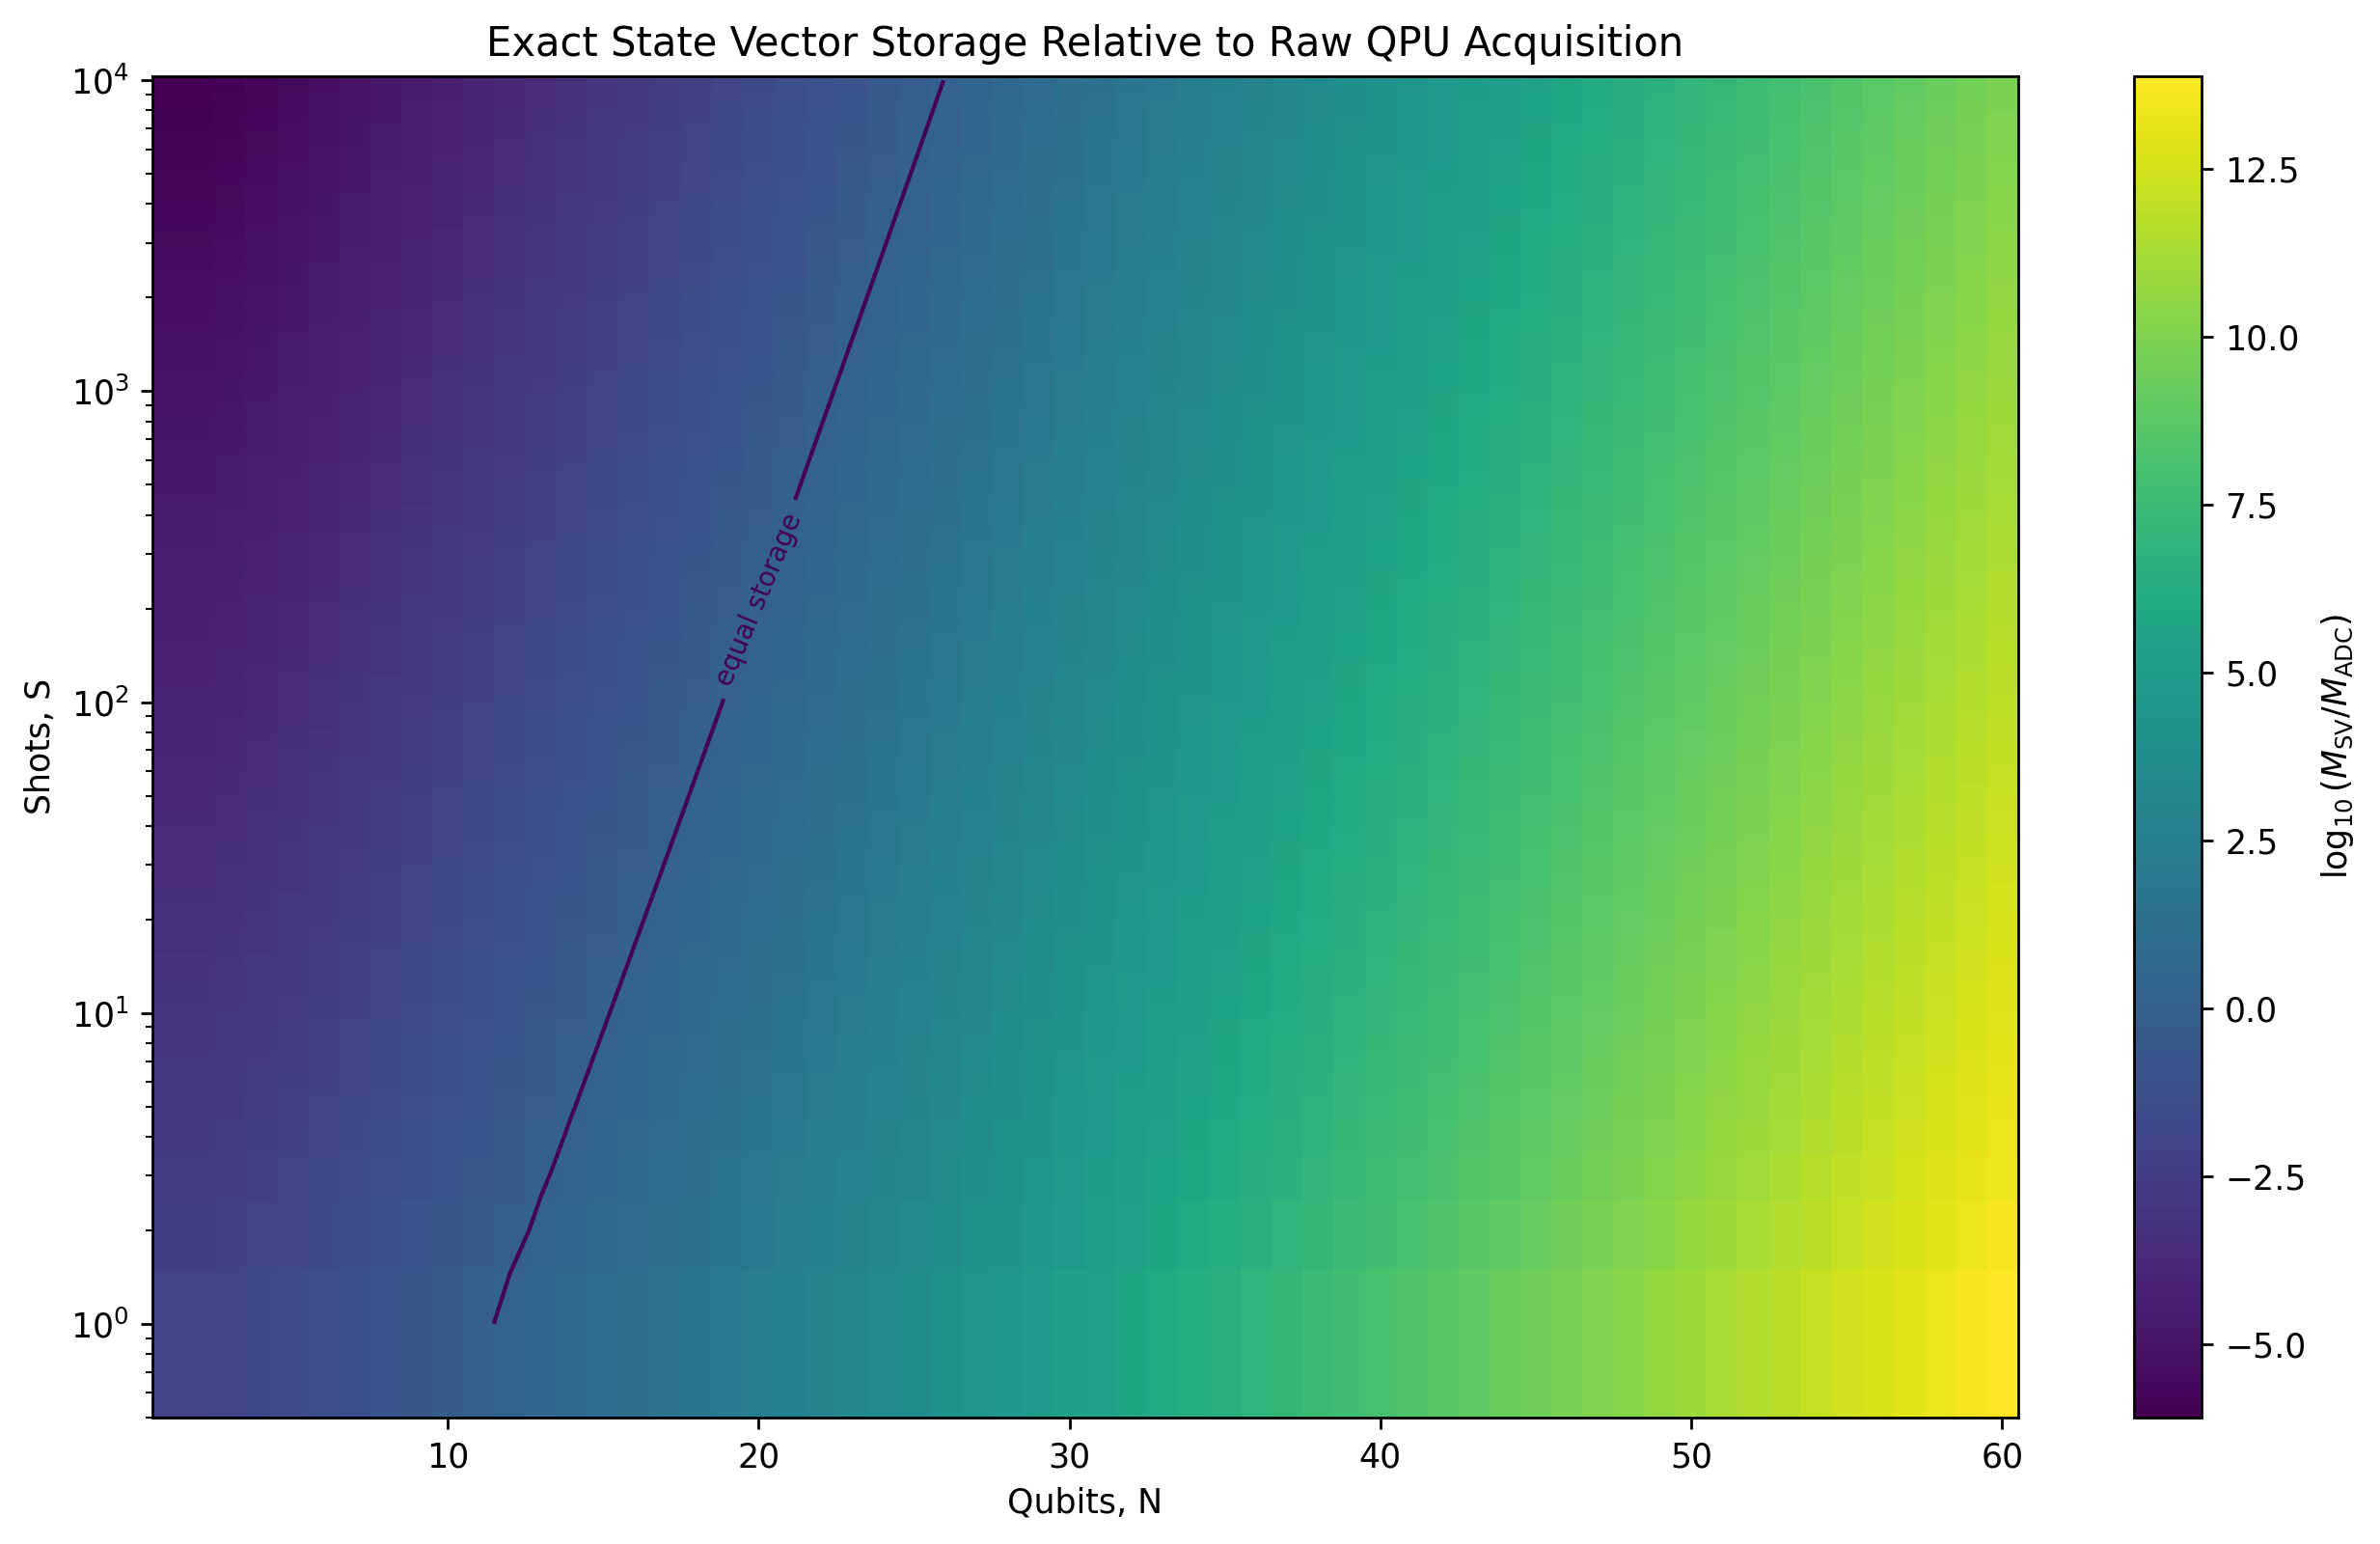

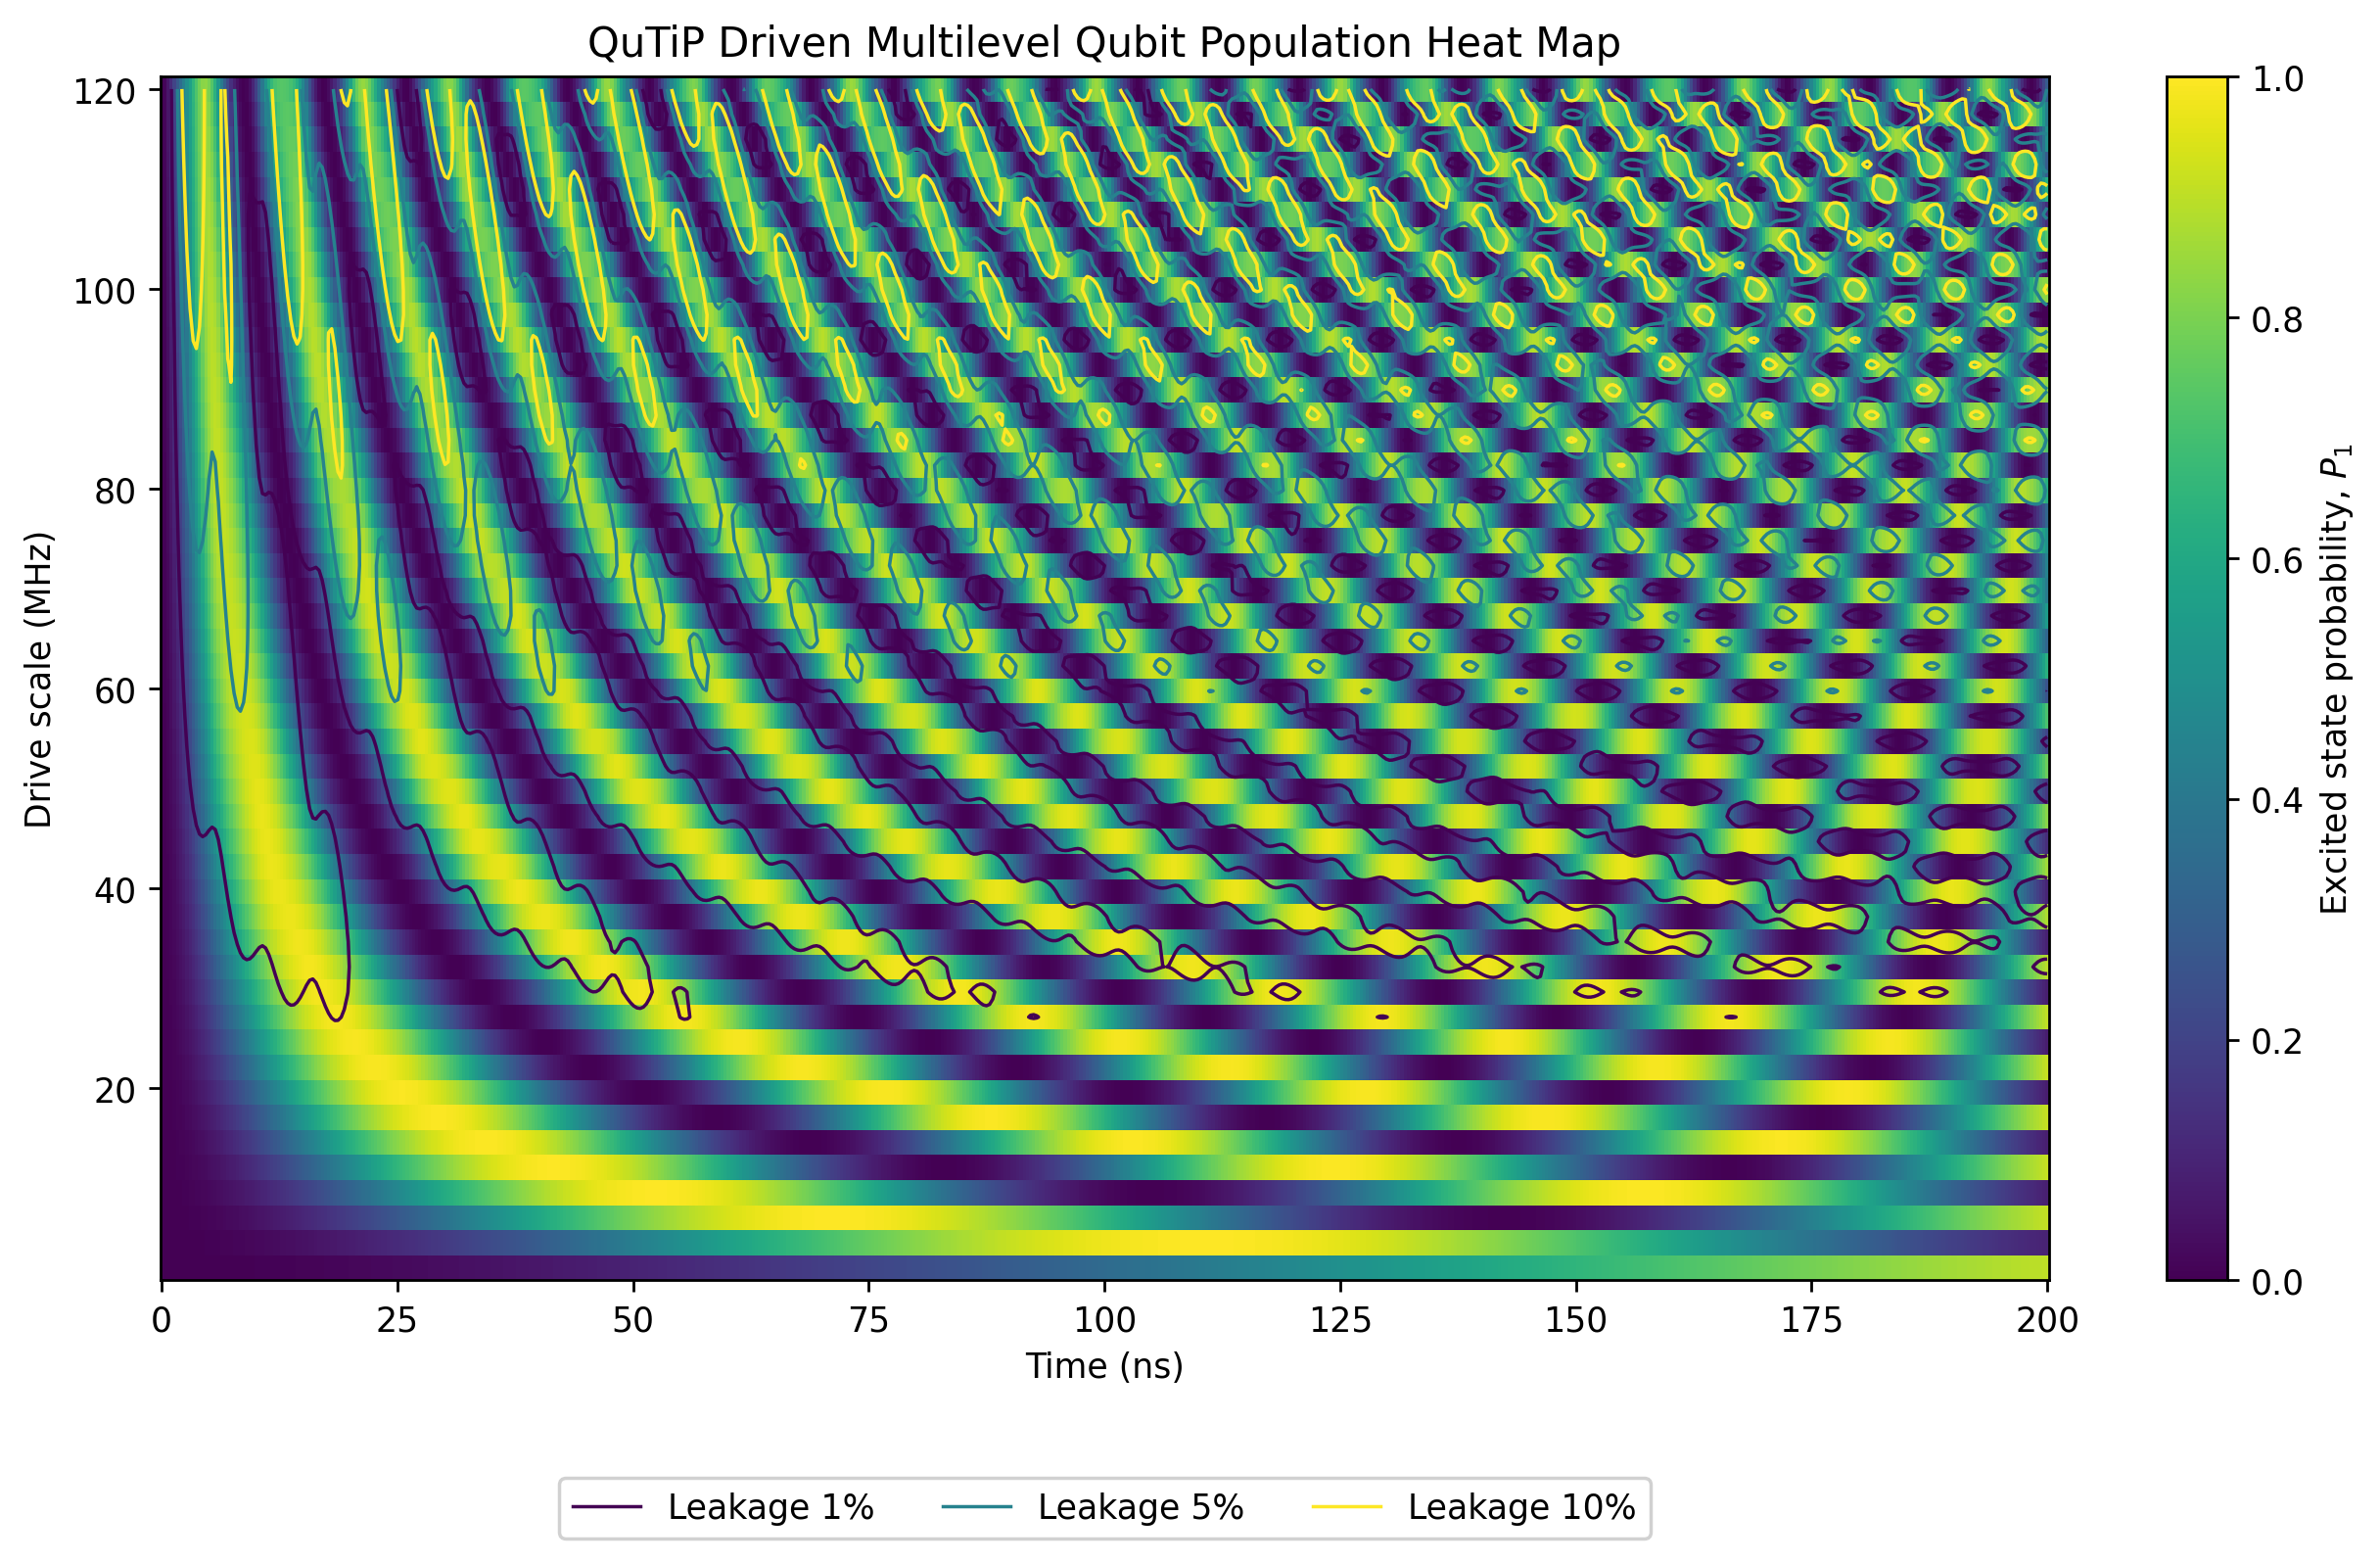

QuTiP drive map maximum computational subspace leakage is 20.965%


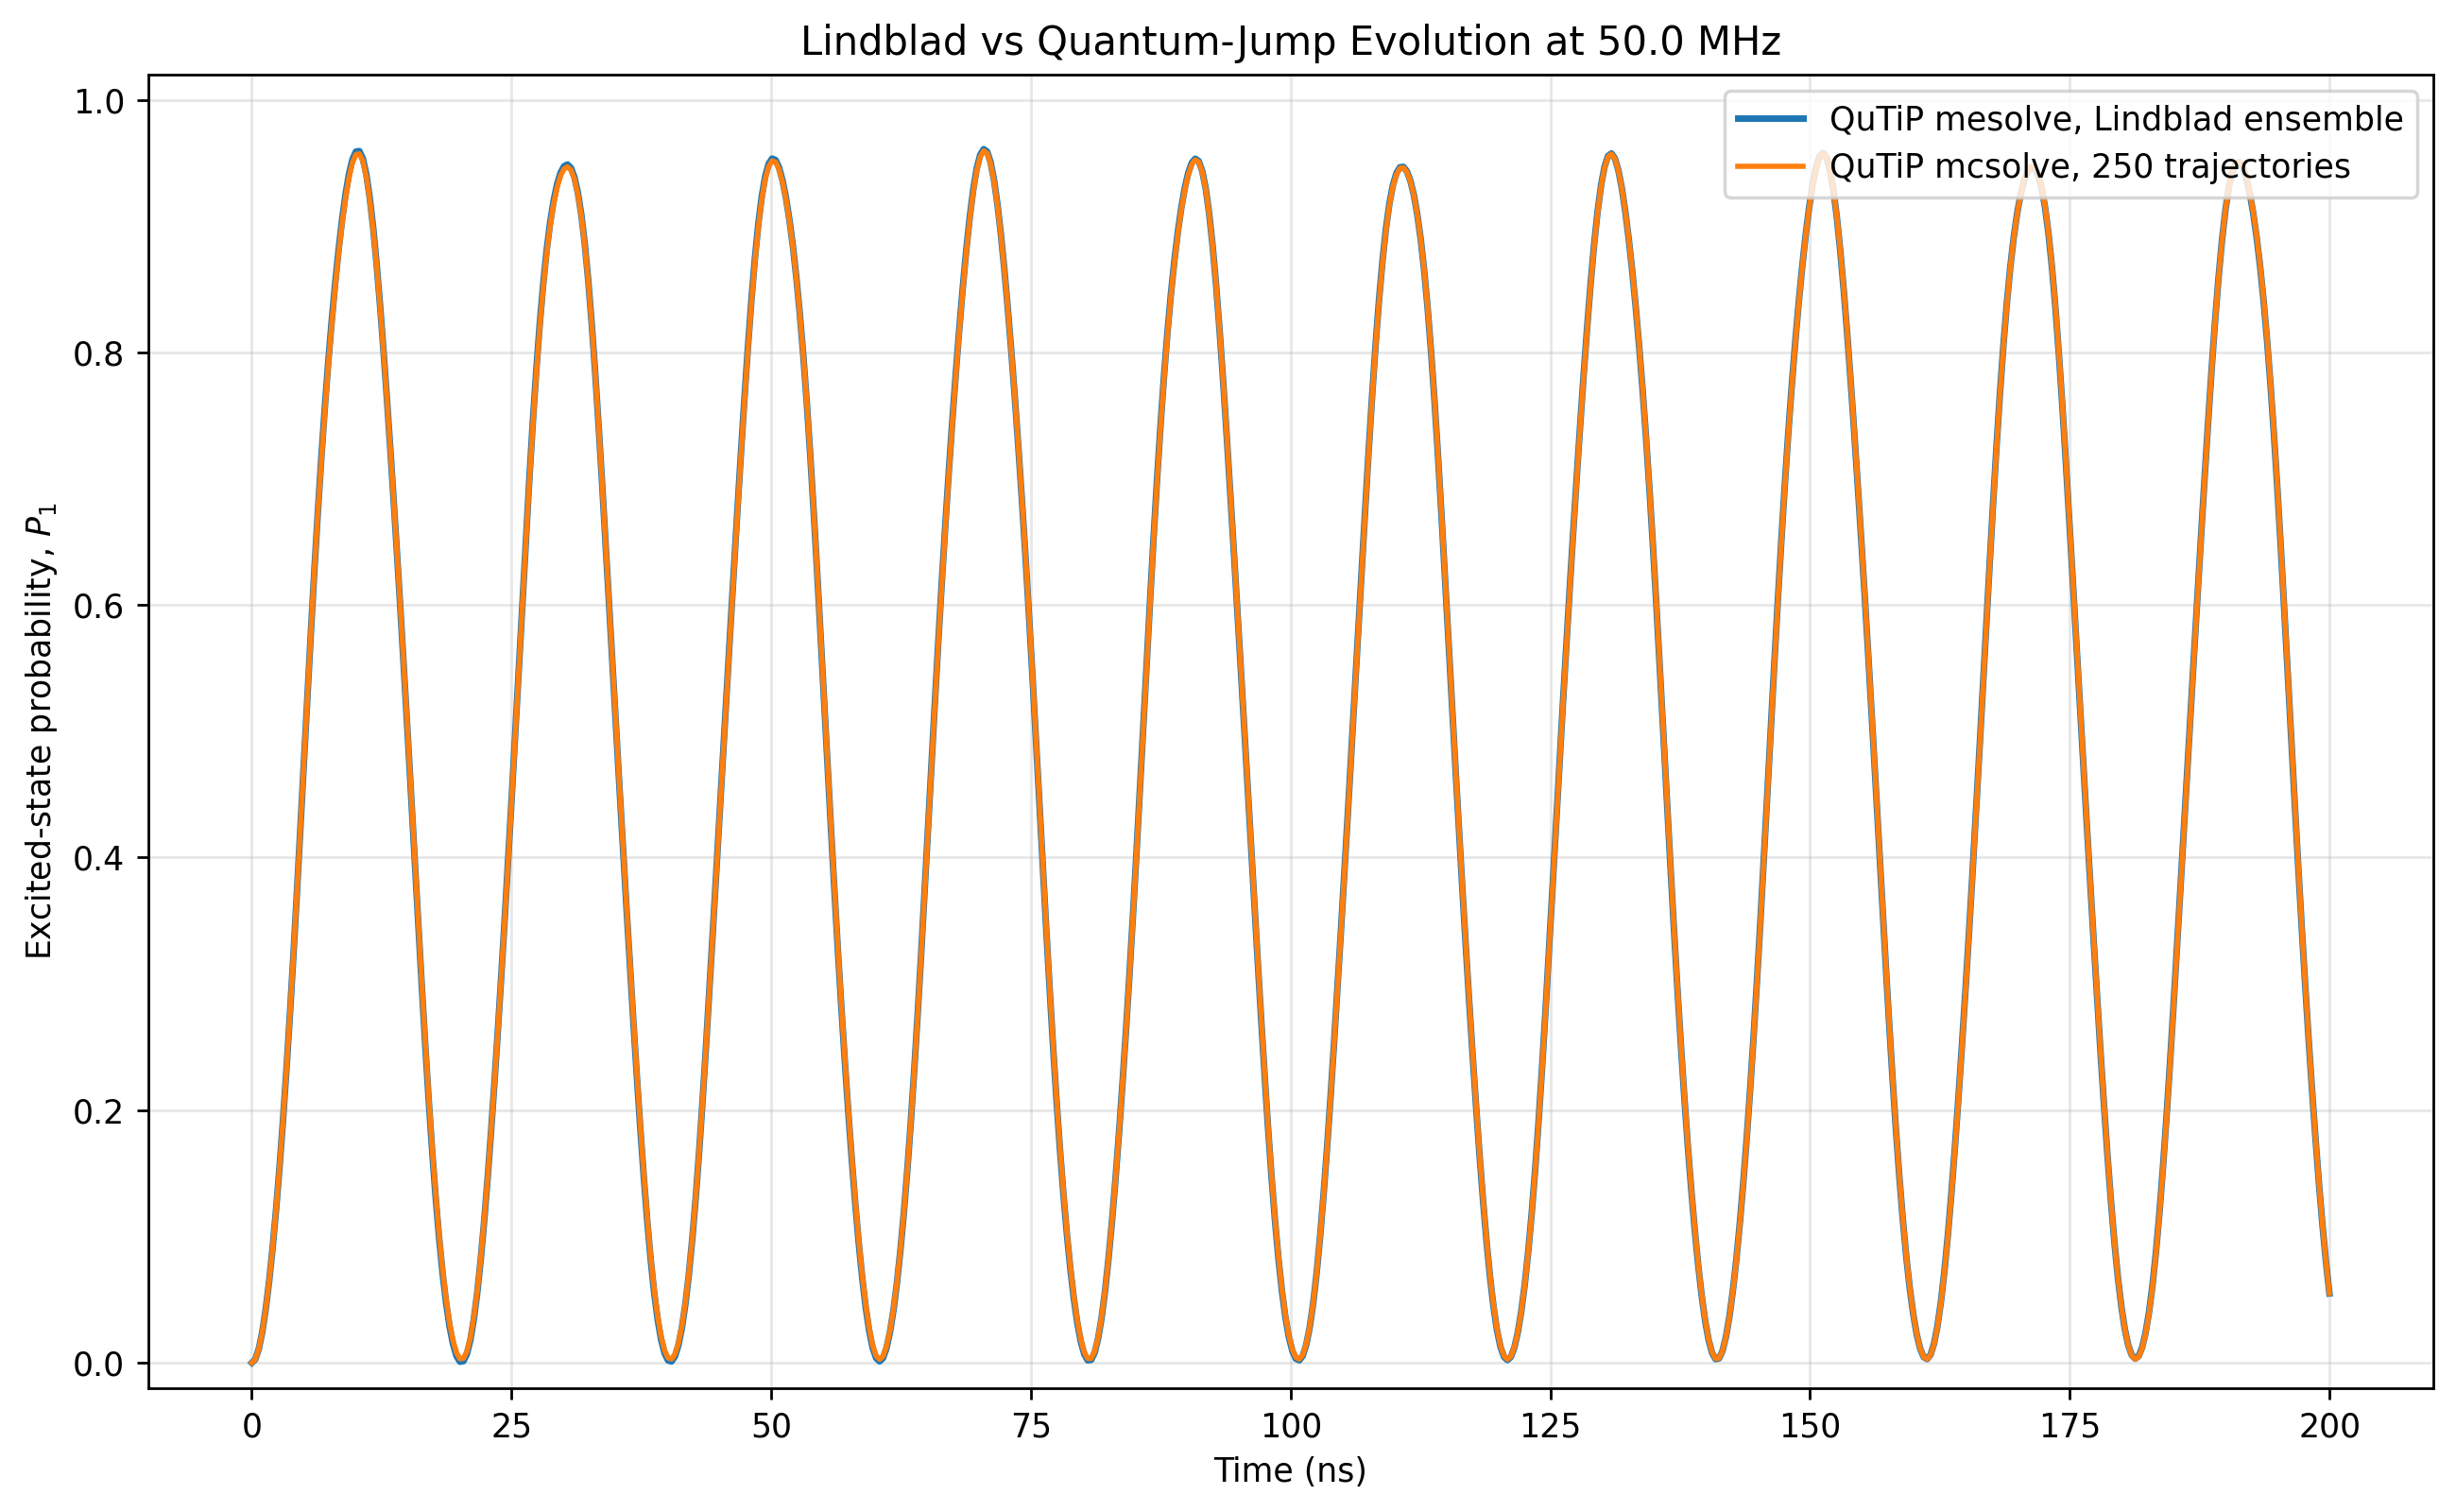

Quantum-jump vs Lindblad P1 RMSE: 0.001486


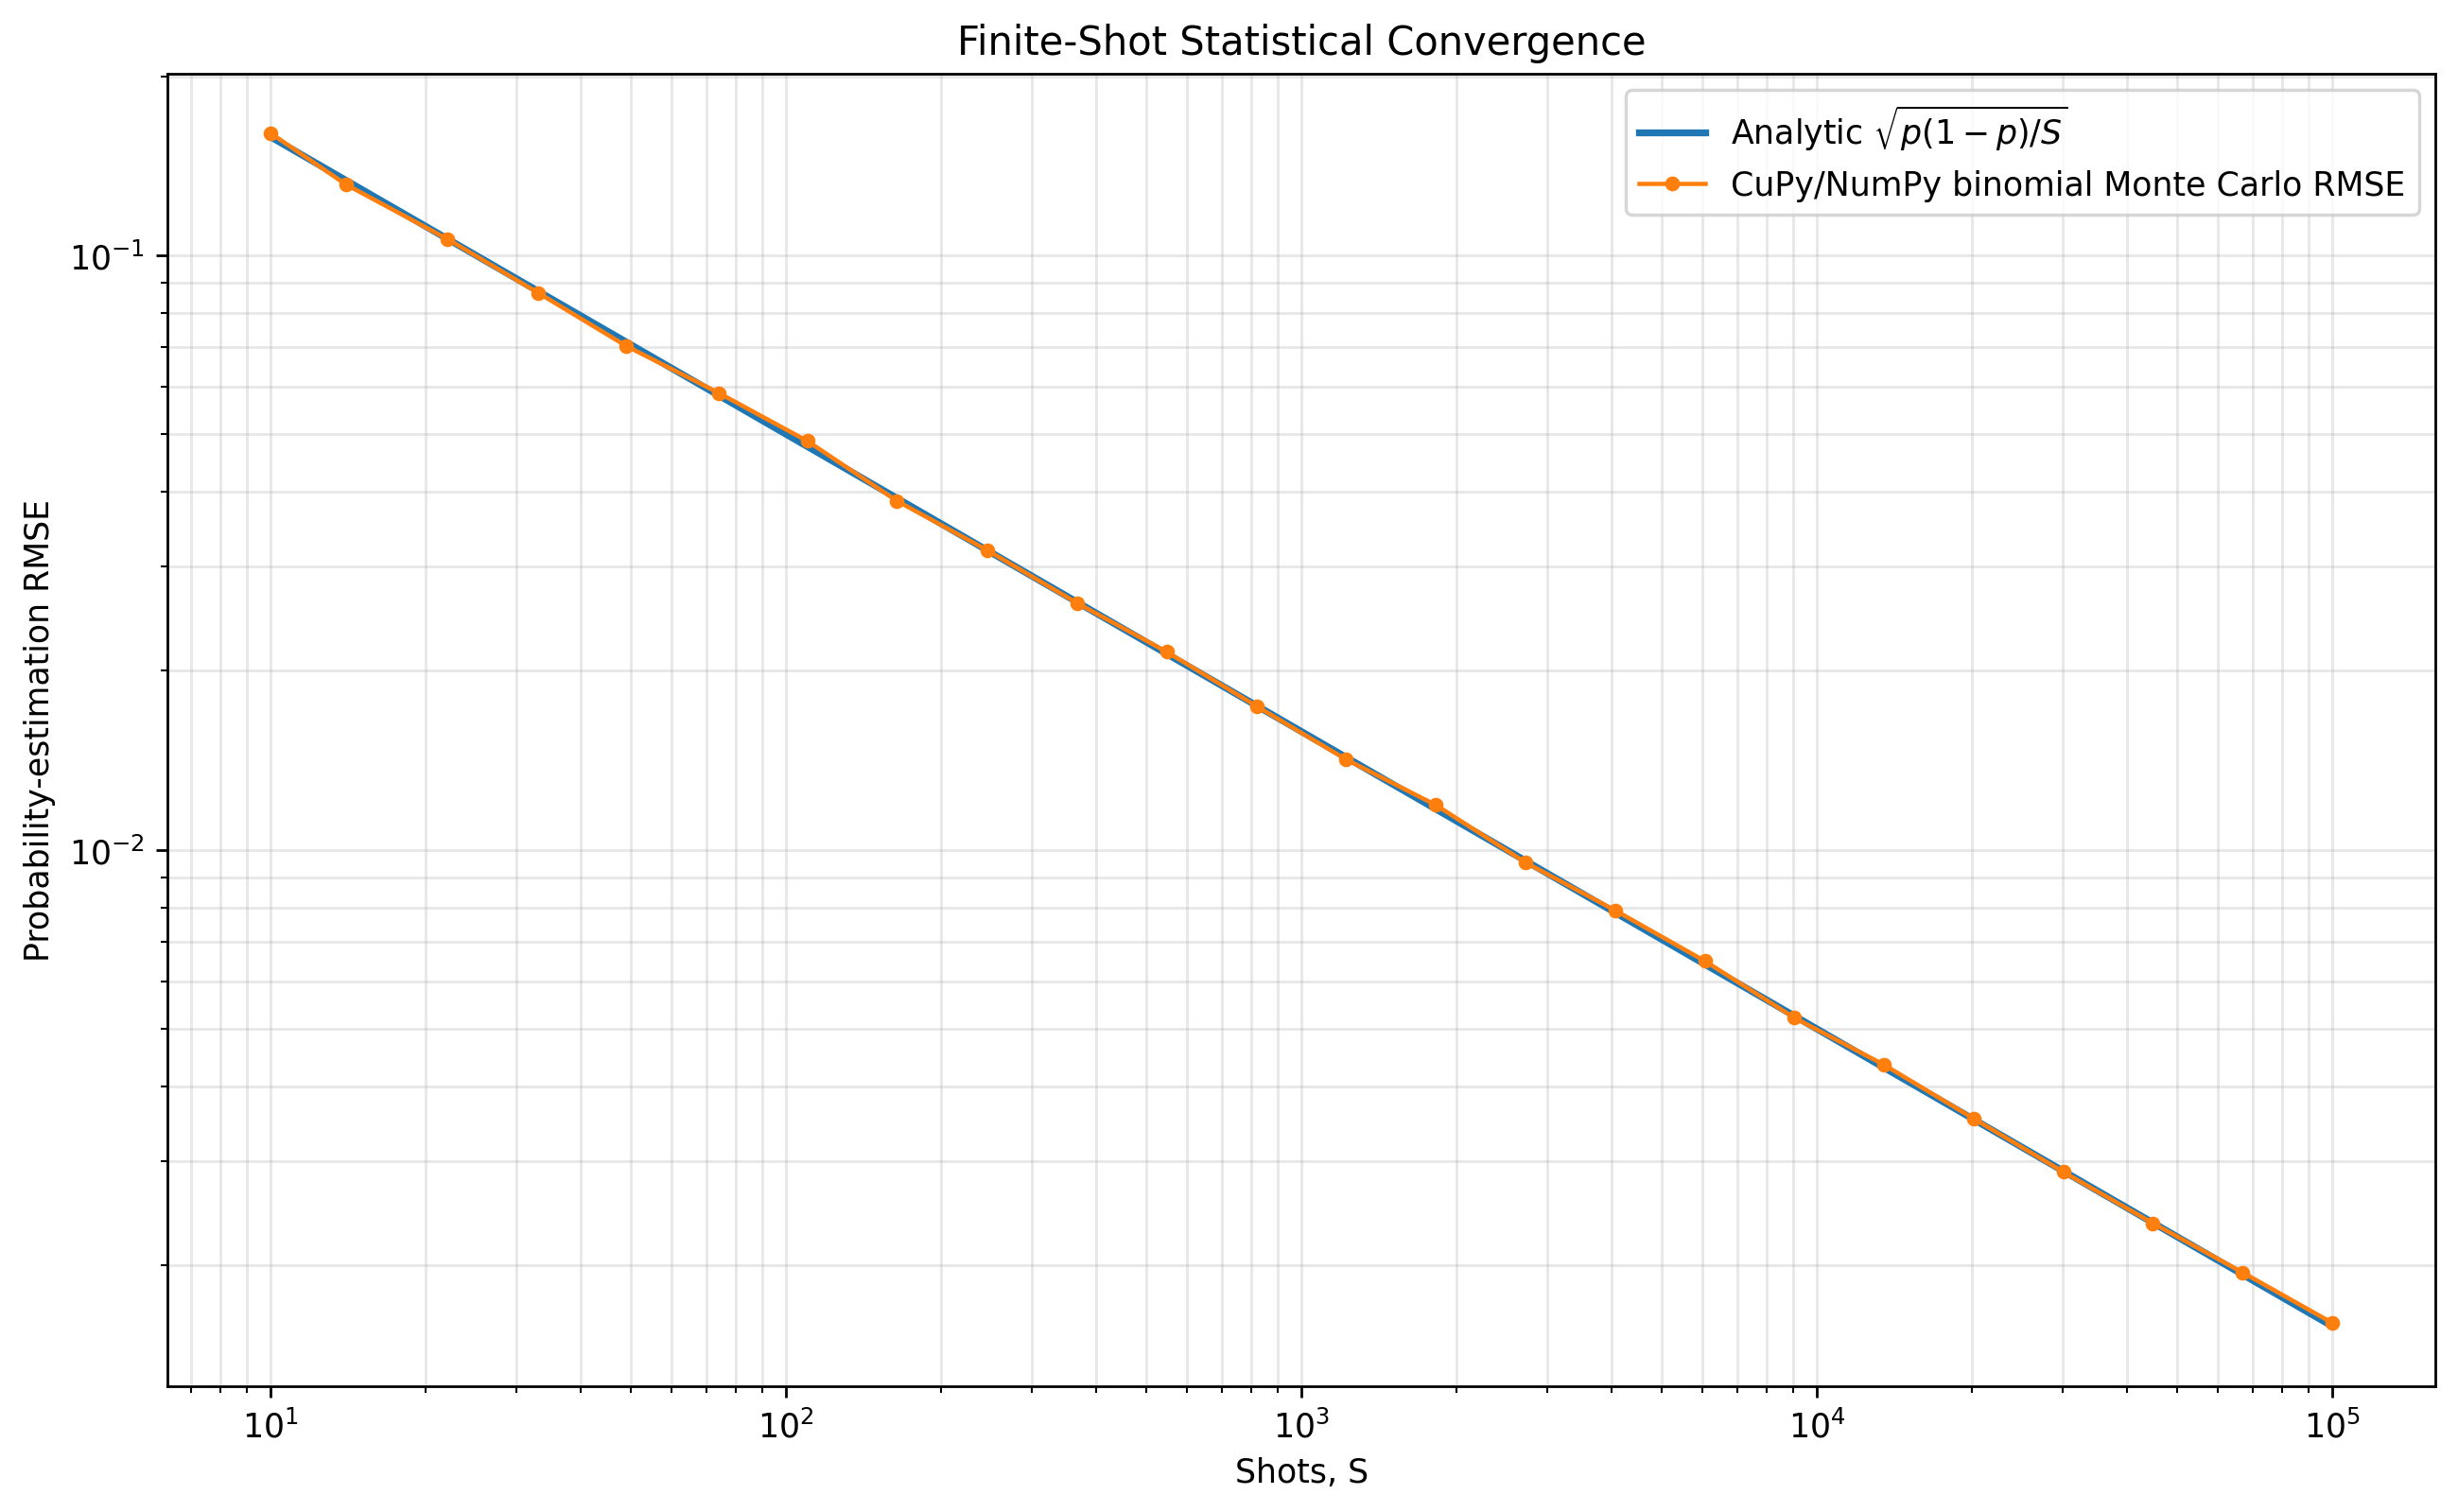

In [8]:
"""Compare physical-qubit acquisition with exact classical simulation resources.

The model separates Hilbert-space dimension, dense transformation storage,
state-vector memory, detector output, active electrical power, and energy.
CuPy accelerates finite-shot statistics and two-dimensional resource grids.
QuTiP adds a tractable local open-system model of a driven multilevel qubit;
it is intentionally not used as an exact simulator for the 10,000-qubit scale.
"""

import math
import warnings
from dataclasses import dataclass
from importlib import metadata
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
from matplotlib.lines import Line2D

try:
    import cupy as cp

    HAS_GPU = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = None
    HAS_GPU = False

QUTIP_IMPORT_ERROR: str | None = None

try:
    from qutip import basis, destroy, mcsolve, mesolve, qeye

    HAS_QUTIP = True
except Exception as exc:  # QuTiP can fail through a compiled SciPy dependency.
    basis = None
    destroy = None
    mcsolve = None
    mesolve = None
    qeye = None
    HAS_QUTIP = False
    QUTIP_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"


# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
MIN_QUBITS = 1
EXTENDED_MAX_QUBITS = 10_000
CLASSICAL_ZOOM_MAX_QUBITS = 60
PLOT_POINTS = 1_400

SHOT_COUNTS = (1, 10_000)
BYTES_PER_COMPLEX128 = np.dtype(np.complex128).itemsize

# Measurement representations.
# Level 2 style classified result, packed into bytes.
BITS_PER_CLASSIFIED_QUBIT = 1

# Integrated I/Q representation, one float32 I and one float32 Q per qubit.
IQ_COMPONENTS = 2
BYTES_PER_IQ_COMPONENT = np.dtype(np.float32).itemsize

# Illustrative raw detector stream. Adjust these to match the acquisition card.
ADC_SAMPLE_RATE_GSPS = 1.0
READOUT_DURATION_NS = 1_000.0
ADC_COMPONENTS = 2
BYTES_PER_ADC_COMPONENT = np.dtype(np.int16).itemsize

# Workstation-laptop scenario.
WORKSTATION_MEMORY_B = 64e9
WORKSTATION_ACTIVE_POWER_W = 150.0
WORKSTATION_MEMORY_BANDWIDTH_BPS = 100e9

# NVIDIA DGX B200 reference and an editable AI-cluster scenario.
DGX_B200_GPU_MEMORY_B = 1_440e9
DGX_B200_HBM_BANDWIDTH_BPS = 64e12
DGX_B200_MAX_SYSTEM_POWER_W = 14_300.0
AI_CLUSTER_DGX_NODES = 1_024
AI_ACTIVE_POWER_FRACTION = 0.75
AI_PUE = 1.20

# Frontier reference values.
FRONTIER_NODE_COUNT = 9_856
FRONTIER_GCDS_PER_NODE = 8
FRONTIER_HBM_PER_GCD_B = 64e9
FRONTIER_HBM_BANDWIDTH_PER_GCD_BPS = 1.6e12
FRONTIER_HOST_MEMORY_PER_NODE_B = 512e9
FRONTIER_TOP500_POWER_W = 24_607_000.0

# Predictive cryogenic-QPU facility scenario.
# The 26 kW value is a planning-scale cryostat assumption. It is intentionally
# exposed here instead of being treated as a universal property of a QPU.
QPU_POWER_PER_CRYOSTAT_W = 26_000.0
QPU_PHYSICAL_QUBITS_PER_CRYOSTAT = 4_158
QPU_SHOT_RUNTIME_US = 100.0

# Classical energy lower-bound model.
# One state-vector pass means reading and writing the full state once.
STATE_VECTOR_PASSES_PER_CIRCUIT = 100
READ_WRITE_TRAFFIC_FACTOR = 2.0

# Monte Carlo controls.
ENABLE_MONTE_CARLO = True
TRUE_BERNOULLI_PROBABILITY = 0.5
MONTE_CARLO_TRIALS = 4_000
MONTE_CARLO_SHOT_MIN = 10
MONTE_CARLO_SHOT_MAX = 100_000
MONTE_CARLO_POINTS = 24
RANDOM_SEED = 7

# QuTiP local-dynamics controls.
ENABLE_QUTIP_DYNAMICS = True
ENABLE_QUTIP_QUANTUM_JUMPS = True
QUTIP_LEVELS = 3
QUTIP_ANHARMONICITY_MHZ = -200.0
QUTIP_DRIVE_MIN_MHZ = 2.0
QUTIP_DRIVE_MAX_MHZ = 120.0
QUTIP_DRIVE_POINTS = 48
QUTIP_TIME_MAX_NS = 200.0
QUTIP_TIME_POINTS = 600
QUTIP_INCLUDE_DECOHERENCE = True
QUTIP_T1_US = 30.0
QUTIP_TPHI_US = 50.0
QUTIP_MC_DRIVE_MHZ = 50.0
QUTIP_MC_TRAJECTORIES = 250

# Two-dimensional resource-separation heat-map controls.
RESOURCE_HEATMAP_MAX_QUBITS = 60
RESOURCE_HEATMAP_SHOT_MIN = 1
RESOURCE_HEATMAP_SHOT_MAX = 10_000
RESOURCE_HEATMAP_SHOT_POINTS = 140

# Plot controls.
FIGSIZE = (10.5, 6.5)
rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
rcParams["font.family"] = "sans-serif"
rcParams["font.weight"] = "normal"
rcParams["figure.dpi"] = 250


# ---------------------------------------------------
# SOURCE METADATA
# ---------------------------------------------------
SOURCE_NOTES = {
    "Frontier hardware": (
        "https://docs.olcf.ornl.gov/systems/frontier_user_guide.html"
    ),
    "Frontier June 2026 TOP500 power": (
        "https://www.top500.org/lists/top500/2026/06/"
    ),
    "NVIDIA DGX B200 specifications": (
        "https://www.nvidia.com/en-us/data-center/dgx-b200/"
    ),
    "Cryogenic-QPU planning context": (
        "https://www.rand.org/pubs/working_papers/WRA2427-1.html"
    ),
    "QuTiP master-equation solver": (
        "https://qutip.readthedocs.io/en/stable/apidoc/solver.html"
    ),
    "QuTiP quantum-jump Monte Carlo": (
        "https://qutip.readthedocs.io/en/stable/guide/dynamics/dynamics-monte.html"
    ),
}


@dataclass(frozen=True)
class ClassicalPlatform:
    """Describe one repeatable classical compute building block."""

    name: str
    memory_per_unit_b: float
    active_power_per_unit_w: float
    bandwidth_per_unit_bps: float
    available_units: int
    power_basis: str

    @property
    def total_memory_b(self) -> float:
        """Return total modeled state-vector memory."""
        return self.memory_per_unit_b * self.available_units

    @property
    def total_active_power_w(self) -> float:
        """Return active power if all modeled units are operating."""
        return self.active_power_per_unit_w * self.available_units

    @property
    def total_bandwidth_bps(self) -> float:
        """Return ideal aggregate memory bandwidth."""
        return self.bandwidth_per_unit_bps * self.available_units


DGX_B200_AVERAGE_FACILITY_POWER_W = (
    DGX_B200_MAX_SYSTEM_POWER_W * AI_ACTIVE_POWER_FRACTION * AI_PUE
)
FRONTIER_HBM_PER_NODE_B = (
    FRONTIER_GCDS_PER_NODE * FRONTIER_HBM_PER_GCD_B
)
FRONTIER_HBM_BANDWIDTH_PER_NODE_BPS = (
    FRONTIER_GCDS_PER_NODE * FRONTIER_HBM_BANDWIDTH_PER_GCD_BPS
)
FRONTIER_POWER_PER_NODE_W = FRONTIER_TOP500_POWER_W / FRONTIER_NODE_COUNT

PLATFORMS = (
    ClassicalPlatform(
        name="Workstation laptop",
        memory_per_unit_b=WORKSTATION_MEMORY_B,
        active_power_per_unit_w=WORKSTATION_ACTIVE_POWER_W,
        bandwidth_per_unit_bps=WORKSTATION_MEMORY_BANDWIDTH_BPS,
        available_units=1,
        power_basis="editable active-power scenario",
    ),
    ClassicalPlatform(
        name=f"AI cluster, {AI_CLUSTER_DGX_NODES:,} DGX B200",
        memory_per_unit_b=DGX_B200_GPU_MEMORY_B,
        active_power_per_unit_w=DGX_B200_AVERAGE_FACILITY_POWER_W,
        bandwidth_per_unit_bps=DGX_B200_HBM_BANDWIDTH_BPS,
        available_units=AI_CLUSTER_DGX_NODES,
        power_basis="75% of nameplate system power with PUE = 1.20",
    ),
    ClassicalPlatform(
        name="Frontier",
        memory_per_unit_b=FRONTIER_HBM_PER_NODE_B,
        active_power_per_unit_w=FRONTIER_POWER_PER_NODE_W,
        bandwidth_per_unit_bps=FRONTIER_HBM_BANDWIDTH_PER_NODE_BPS,
        available_units=FRONTIER_NODE_COUNT,
        power_basis="June 2026 TOP500 benchmark power apportioned per node",
    ),
)


# ---------------------------------------------------
# QUANTUM AND CLASSICAL REPRESENTATION CALCULATIONS
# ---------------------------------------------------
def hilbert_log10_dimension(num_qubits: np.ndarray | float) -> np.ndarray:
    """Return log10 of the Hilbert-space dimension 2**N."""
    qubits = np.asarray(num_qubits, dtype=np.float64)
    return qubits * math.log10(2.0)


def dense_unitary_log10_elements(
    num_qubits: np.ndarray | float,
) -> np.ndarray:
    """Return log10 of the element count of a dense 2**N by 2**N unitary."""
    return 2.0 * hilbert_log10_dimension(num_qubits)


def state_vector_log10_bytes(
    num_qubits: np.ndarray | float,
) -> np.ndarray:
    """Return log10 bytes for one complex128 state vector."""
    return (
        math.log10(BYTES_PER_COMPLEX128)
        + hilbert_log10_dimension(num_qubits)
    )


def dense_unitary_log10_bytes(
    num_qubits: np.ndarray | float,
) -> np.ndarray:
    """Return log10 bytes for a fully materialized dense complex128 unitary."""
    return (
        math.log10(BYTES_PER_COMPLEX128)
        + dense_unitary_log10_elements(num_qubits)
    )


def classified_output_bytes(
    num_qubits: np.ndarray | int,
    shots: int,
) -> np.ndarray:
    """Return packed computational-basis result bytes."""
    qubits = np.asarray(num_qubits, dtype=np.int64)
    bytes_per_shot = np.ceil(
        qubits * BITS_PER_CLASSIFIED_QUBIT / 8.0
    )
    return bytes_per_shot.astype(np.float64) * float(shots)


def integrated_iq_output_bytes(
    num_qubits: np.ndarray | int,
    shots: int,
) -> np.ndarray:
    """Return bytes for one float32 I/Q pair per qubit and shot."""
    qubits = np.asarray(num_qubits, dtype=np.float64)
    bytes_per_qubit = IQ_COMPONENTS * BYTES_PER_IQ_COMPONENT
    return qubits * bytes_per_qubit * float(shots)


def adc_samples_per_readout() -> int:
    """Return ADC sample count for one readout window."""
    samples = ADC_SAMPLE_RATE_GSPS * READOUT_DURATION_NS
    return int(math.ceil(samples))


def raw_adc_output_bytes(
    num_qubits: np.ndarray | int,
    shots: int,
) -> np.ndarray:
    """Return raw I/Q ADC payload bytes for the configured readout window."""
    qubits = np.asarray(num_qubits, dtype=np.float64)
    bytes_per_qubit_shot = (
        adc_samples_per_readout()
        * ADC_COMPONENTS
        * BYTES_PER_ADC_COMPONENT
    )
    return qubits * bytes_per_qubit_shot * float(shots)


def max_state_vector_qubits(memory_bytes: float) -> int:
    """Return the ideal raw complex128 state-vector memory ceiling."""
    return math.floor(math.log2(memory_bytes / BYTES_PER_COMPLEX128))


def max_dense_unitary_qubits(memory_bytes: float) -> int:
    """Return the ideal raw dense-unitary memory ceiling."""
    return math.floor(
        0.5 * math.log2(memory_bytes / BYTES_PER_COMPLEX128)
    )


def cryostats_required(num_qubits: np.ndarray | int) -> np.ndarray:
    """Return cryostat count under the editable physical-qubit capacity model."""
    qubits = np.asarray(num_qubits, dtype=np.float64)
    return np.maximum(
        1.0,
        np.ceil(qubits / QPU_PHYSICAL_QUBITS_PER_CRYOSTAT),
    )


def qpu_average_facility_power_w(
    num_qubits: np.ndarray | int,
) -> np.ndarray:
    """Return predicted QPU facility power under the cryostat scenario."""
    return cryostats_required(num_qubits) * QPU_POWER_PER_CRYOSTAT_W


# ---------------------------------------------------
# CLASSICAL POWER AND ENERGY MODELS
# ---------------------------------------------------
def platform_capacity_qubits(platform: ClassicalPlatform) -> int:
    """Return maximum ideal state-vector qubits for a fixed platform."""
    return max_state_vector_qubits(platform.total_memory_b)


def required_units_for_state_vector(
    num_qubits: int,
    platform: ClassicalPlatform,
) -> int:
    """Return exact integer units needed over the numerically safe range."""
    log_ratio = (
        float(state_vector_log10_bytes(num_qubits))
        - math.log10(platform.memory_per_unit_b)
    )
    if log_ratio <= 0.0:
        return 1
    if log_ratio > 15.0:
        raise OverflowError(
            "Unit count is too large for exact integer construction. "
            "Use the logarithmic extrapolation helper."
        )
    return int(math.ceil(10.0**log_ratio))


def scalable_memory_power_floor_log10_w(
    num_qubits: np.ndarray,
    platform: ClassicalPlatform,
) -> np.ndarray:
    """Return log10 of a memory-capacity lower bound on active power.

    The extrapolation assumes repeatable units with ideal interconnect and uses
    enough aggregate memory to hold one complex128 state vector. It is a
    capacity floor rather than a simulator power benchmark.
    """
    state_log = state_vector_log10_bytes(num_qubits)
    log_units_continuous = np.maximum(
        0.0,
        state_log - math.log10(platform.memory_per_unit_b),
    )
    return math.log10(platform.active_power_per_unit_w) + log_units_continuous


def classical_memory_pass_energy_log10_j(
    num_qubits: np.ndarray,
    platform: ClassicalPlatform,
    shots: int,
    independent_reruns: bool,
) -> np.ndarray:
    """Return ideal memory-traffic energy floor for exact state evolution.

    Perfect linear bandwidth scaling is assumed. Each state-vector pass reads
    and writes the full state. Communication, arithmetic, synchronization,
    host-device traffic, and checkpointing all increase real time and energy.

    Args:
        num_qubits: Qubit counts.
        platform: Repeatable classical hardware building block.
        shots: Requested measurement shots.
        independent_reruns: If True, every shot repeats state evolution. If
            False, one final noiseless state is reused for repeated sampling.

    Returns:
        log10 of the estimated lower-bound energy in joules.
    """
    multiplier = float(shots) if independent_reruns else 1.0
    coefficient = (
        READ_WRITE_TRAFFIC_FACTOR
        * STATE_VECTOR_PASSES_PER_CIRCUIT
        * platform.active_power_per_unit_w
        * multiplier
        / platform.bandwidth_per_unit_bps
    )
    return state_vector_log10_bytes(num_qubits) + math.log10(coefficient)


def qpu_experiment_energy_j(
    num_qubits: np.ndarray,
    shots: int,
) -> np.ndarray:
    """Return facility-energy scenario for repeated physical QPU shots."""
    shot_seconds = QPU_SHOT_RUNTIME_US * 1e-6
    return qpu_average_facility_power_w(num_qubits) * shot_seconds * shots


# ---------------------------------------------------
# MONTE CARLO SHOT STATISTICS
# ---------------------------------------------------
def theoretical_binomial_standard_error(
    shots: np.ndarray,
    probability: float,
) -> np.ndarray:
    """Return Bernoulli probability-estimator standard error."""
    shot_array = np.asarray(shots, dtype=np.float64)
    return np.sqrt(probability * (1.0 - probability) / shot_array)


def simulate_binomial_rmse(
    shots: np.ndarray,
    probability: float,
    trials: int,
) -> np.ndarray:
    """Estimate finite-shot RMSE with independent binomial Monte Carlo."""
    shot_array = np.asarray(shots, dtype=np.int64)
    rmse = np.empty(shot_array.size, dtype=np.float64)

    if HAS_GPU:
        cp.random.seed(RANDOM_SEED)
        for index, shot_count in enumerate(shot_array):
            successes = cp.random.binomial(
                int(shot_count),
                probability,
                size=trials,
            )
            estimates = successes / float(shot_count)
            rmse[index] = float(
                cp.sqrt(cp.mean((estimates - probability) ** 2)).get()
            )
        return rmse

    rng = np.random.default_rng(RANDOM_SEED)
    for index, shot_count in enumerate(shot_array):
        successes = rng.binomial(
            int(shot_count),
            probability,
            size=trials,
        )
        estimates = successes / float(shot_count)
        rmse[index] = np.sqrt(
            np.mean((estimates - probability) ** 2)
        )

    return rmse


# ---------------------------------------------------
# QUTIP LOCAL QUANTUM-DYNAMICS MODEL
# ---------------------------------------------------
def mhz_to_rad_per_ns(frequency_mhz: float) -> float:
    """Convert a cyclic frequency in MHz to angular frequency in rad/ns."""
    return 2.0 * math.pi * frequency_mhz * 1e-3


def build_qutip_duffing_model(drive_mhz: float):
    """Build a rotating-frame driven Duffing Hamiltonian and observables.

    The model is a weakly anharmonic oscillator truncated to QUTIP_LEVELS:

        H / hbar = alpha / 2 * n * (n - 1) + Omega / 2 * (a + a^dagger)

    where the drive is resonant with the 0-to-1 transition in this frame.

    Args:
        drive_mhz: Resonant Rabi-drive scale in MHz.

    Returns:
        Hamiltonian, initial state, collapse operators, P1 projector, and
        computational-subspace leakage operator.
    """
    if not HAS_QUTIP:
        raise RuntimeError("QuTiP is unavailable in this Python environment.")

    annihilation = destroy(QUTIP_LEVELS)
    number = annihilation.dag() * annihilation
    identity = qeye(QUTIP_LEVELS)

    alpha = mhz_to_rad_per_ns(QUTIP_ANHARMONICITY_MHZ)
    omega = mhz_to_rad_per_ns(drive_mhz)

    hamiltonian = (
        0.5 * alpha * number * (number - identity)
        + 0.5 * omega * (annihilation + annihilation.dag())
    )

    initial_state = basis(QUTIP_LEVELS, 0)
    p0 = basis(QUTIP_LEVELS, 0).proj()
    p1 = basis(QUTIP_LEVELS, 1).proj()
    leakage = identity - p0 - p1

    collapse_ops = []
    if QUTIP_INCLUDE_DECOHERENCE:
        if QUTIP_T1_US > 0.0:
            gamma_1_per_ns = 1.0 / (QUTIP_T1_US * 1e3)
            collapse_ops.append(math.sqrt(gamma_1_per_ns) * annihilation)

        if QUTIP_TPHI_US > 0.0:
            # D[n] damps rho_01 at half its coefficient. The factor of two
            # therefore makes the 0-to-1 pure-dephasing time equal T_phi.
            gamma_phi_per_ns = 2.0 / (QUTIP_TPHI_US * 1e3)
            collapse_ops.append(math.sqrt(gamma_phi_per_ns) * number)

    return hamiltonian, initial_state, collapse_ops, p1, leakage


def solve_qutip_drive_heatmap() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Solve P1 and leakage versus time and drive strength with QuTiP."""
    if not HAS_QUTIP:
        raise RuntimeError("QuTiP is unavailable in this Python environment.")

    times_ns = np.linspace(0.0, QUTIP_TIME_MAX_NS, QUTIP_TIME_POINTS)
    drives_mhz = np.linspace(
        QUTIP_DRIVE_MIN_MHZ,
        QUTIP_DRIVE_MAX_MHZ,
        QUTIP_DRIVE_POINTS,
    )
    p1_map = np.empty((drives_mhz.size, times_ns.size), dtype=np.float64)
    leakage_map = np.empty_like(p1_map)

    solver_options = {
        "store_states": False,
        "progress_bar": "",
        "atol": 1e-9,
        "rtol": 1e-7,
        "nsteps": 10_000,
    }

    for row, drive_mhz in enumerate(drives_mhz):
        hamiltonian, psi0, c_ops, p1, leakage = build_qutip_duffing_model(
            float(drive_mhz)
        )
        result = mesolve(
            hamiltonian,
            psi0,
            times_ns,
            c_ops,
            e_ops=[p1, leakage],
            options=solver_options,
        )
        p1_map[row] = np.real_if_close(result.expect[0]).astype(np.float64)
        leakage_map[row] = np.real_if_close(result.expect[1]).astype(np.float64)

    np.clip(p1_map, 0.0, 1.0, out=p1_map)
    np.clip(leakage_map, 0.0, 1.0, out=leakage_map)
    return times_ns, drives_mhz, p1_map, leakage_map


def solve_qutip_quantum_jump_check() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compare deterministic Lindblad and quantum-jump estimates of P1."""
    if not HAS_QUTIP:
        raise RuntimeError("QuTiP is unavailable in this Python environment.")

    times_ns = np.linspace(0.0, QUTIP_TIME_MAX_NS, QUTIP_TIME_POINTS)
    hamiltonian, psi0, c_ops, p1, _ = build_qutip_duffing_model(
        QUTIP_MC_DRIVE_MHZ
    )

    deterministic = mesolve(
        hamiltonian,
        psi0,
        times_ns,
        c_ops,
        e_ops=[p1],
        options={
            "store_states": False,
            "progress_bar": "",
            "nsteps": 10_000,
        },
    )
    lindblad_p1 = np.real_if_close(deterministic.expect[0]).astype(
        np.float64
    )

    if not c_ops:
        return times_ns, lindblad_p1, lindblad_p1.copy()

    stochastic = mcsolve(
        hamiltonian,
        psi0,
        times_ns,
        c_ops,
        e_ops=[p1],
        ntraj=QUTIP_MC_TRAJECTORIES,
        seeds=RANDOM_SEED,
        options={
            "store_states": False,
            "progress_bar": "",
            "map": "serial",
            "nsteps": 10_000,
        },
    )
    jump_p1 = np.real_if_close(stochastic.average_expect[0]).astype(
        np.float64
    )
    return times_ns, lindblad_p1, jump_p1


# ---------------------------------------------------
# GPU/CPU TWO-DIMENSIONAL RESOURCE GRID
# ---------------------------------------------------
def compute_resource_separation_grid() -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute log10(state-vector bytes / raw ADC bytes) over N and shots.

    Positive values mean exact classical state-vector storage is larger than
    the configured physical raw-ADC record. Negative values mean the detector
    record is larger. CuPy computes the grid whenever a CUDA device exists.
    """
    qubits = np.arange(1, RESOURCE_HEATMAP_MAX_QUBITS + 1, dtype=np.int64)
    shots = np.unique(
        np.logspace(
            math.log10(RESOURCE_HEATMAP_SHOT_MIN),
            math.log10(RESOURCE_HEATMAP_SHOT_MAX),
            RESOURCE_HEATMAP_SHOT_POINTS,
        ).astype(np.int64)
    )

    xp = cp if HAS_GPU else np
    qubits_xp = xp.asarray(qubits, dtype=xp.float64)
    shots_xp = xp.asarray(shots, dtype=xp.float64)
    qubit_grid, shot_grid = xp.meshgrid(qubits_xp, shots_xp)

    state_log10 = (
        math.log10(BYTES_PER_COMPLEX128)
        + qubit_grid * math.log10(2.0)
    )
    raw_adc_bytes = (
        qubit_grid
        * shot_grid
        * adc_samples_per_readout()
        * ADC_COMPONENTS
        * BYTES_PER_ADC_COMPONENT
    )
    separation = state_log10 - xp.log10(raw_adc_bytes)

    if HAS_GPU:
        separation = cp.asnumpy(separation)

    return qubits, shots, np.asarray(separation, dtype=np.float64)


def raw_adc_crossover_qubits(shots: int) -> int | None:
    """Return first N where exact state-vector bytes exceed raw ADC bytes."""
    for qubits in range(1, RESOURCE_HEATMAP_MAX_QUBITS + 1):
        state_log10 = float(state_vector_log10_bytes(qubits))
        adc_log10 = math.log10(float(raw_adc_output_bytes(qubits, shots)))
        if state_log10 >= adc_log10:
            return qubits
    return None


# ---------------------------------------------------
# NUMERICAL-STACK DIAGNOSTICS
# ---------------------------------------------------
def installed_version(distribution: str) -> str:
    """Return an installed distribution version without importing it."""
    try:
        return metadata.version(distribution)
    except metadata.PackageNotFoundError:
        return "unavailable"


def validate_numerical_stack() -> None:
    """Report numerical-library versions and optional-backend health.

    QuTiP imports SciPy and compiled extension modules. A Colab session can
    become inconsistent if NumPy or SciPy is upgraded after either library
    has already been imported. This diagnostic exposes that state and allows
    the resource analysis to continue if QuTiP is temporarily unavailable.
    """
    print("\nNUMERICAL STACK")
    print("=" * 94)
    print(f"NumPy: {np.__version__}")
    print(f"SciPy distribution: {installed_version('scipy')}")
    print(f"Matplotlib: {installed_version('matplotlib')}")
    print(f"CuPy distribution: {installed_version('cupy-cuda12x')}")
    print(f"QuTiP distribution: {installed_version('qutip')}")
    print(f"CUDA device available to CuPy: {HAS_GPU}")
    print(f"QuTiP import healthy: {HAS_QUTIP}")

    if QUTIP_IMPORT_ERROR is not None:
        print(f"QuTiP import error: {QUTIP_IMPORT_ERROR}")
        print(
            "QuTiP-dependent plots will be skipped. In Colab, restart the "
            "runtime if NumPy or SciPy was upgraded earlier in this session, "
            "then install QuTiP without upgrading NumPy/SciPy."
        )

    print("=" * 94)


# ---------------------------------------------------
# REPORTING HELPERS
# ---------------------------------------------------
def human_bytes(value: float) -> str:
    """Format a finite byte count with decimal SI prefixes."""
    units = ("B", "kB", "MB", "GB", "TB", "PB", "EB")
    scaled = float(value)
    for unit in units:
        if abs(scaled) < 1_000.0 or unit == units[-1]:
            return f"{scaled:,.3f} {unit}"
        scaled /= 1_000.0
    return f"{scaled:,.3f} EB"


def print_concept_primer() -> None:
    """Print the physical interpretation used by every plot."""
    print("\nPHYSICAL INTERPRETATION")
    print("=" * 94)
    print(
        "An N-qubit register has Hilbert-space dimension 2^N. A quantum gate "
        "is represented mathematically by a unitary transformation, and a "
        "physical QPU realizes the dynamics with its Hamiltonian and controls."
    )
    print(
        "A classified measurement shot returns N classical bits before packing. "
        "Integrated I/Q records and raw ADC streams carry larger detector "
        "payloads, yet neither exposes all 2^N complex state amplitudes."
    )
    print(
        "Exact classical state-vector simulation stores 2^N complex amplitudes. "
        "A fully materialized dense N-qubit unitary would store 4^N complex "
        "entries, although practical simulators usually apply local gates "
        "without constructing that global matrix."
    )
    print(
        "The QuTiP section solves a three-level driven Duffing model only. It "
        "demonstrates local Hamiltonian evolution, leakage, decoherence, and "
        "quantum-jump sampling without extrapolating QuTiP to 10,000 qubits."
    )
    print("=" * 94)


def print_platform_table(platforms: Iterable[ClassicalPlatform]) -> None:
    """Print fixed-system memory ceilings and modeled power references."""
    print("\nFIXED CLASSICAL SYSTEM REFERENCES")
    print("=" * 124)
    header = (
        f"{'System':34s} {'HBM/state memory':>18s} {'Avg active power':>18s} "
        f"{'SV max N':>10s} {'Dense U max N':>14s} {'Power basis':>25s}"
    )
    print(header)
    print("-" * 124)

    for platform in platforms:
        print(
            f"{platform.name:34s} "
            f"{human_bytes(platform.total_memory_b):>18s} "
            f"{platform.total_active_power_w / 1e6:17.6f} MW "
            f"{max_state_vector_qubits(platform.total_memory_b):10d} "
            f"{max_dense_unitary_qubits(platform.total_memory_b):14d} "
            f"{platform.power_basis:>25s}"
        )

    print("=" * 124)
    print(
        "The state-vector ceilings use complex128 storage alone. Simulator "
        "workspace and communication buffers lower practical limits."
    )


def print_endpoint_table(qubit_counts: Iterable[int]) -> None:
    """Print representative quantum-output and classical-memory endpoints."""
    print("\nREPRESENTATIVE DATA VOLUMES")
    print("=" * 126)
    print(
        f"{'N':>8s} {'log10 Hilbert':>14s} {'log10 SV bytes':>15s} "
        f"{'1-shot bits':>15s} {'1-shot I/Q':>15s} "
        f"{'1-shot ADC':>15s} {'10k-shot ADC':>17s}"
    )
    print("-" * 126)

    for qubits in qubit_counts:
        bit_bytes = float(classified_output_bytes(qubits, 1))
        iq_bytes = float(integrated_iq_output_bytes(qubits, 1))
        adc_one = float(raw_adc_output_bytes(qubits, 1))
        adc_many = float(raw_adc_output_bytes(qubits, 10_000))
        print(
            f"{qubits:8,d} "
            f"{float(hilbert_log10_dimension(qubits)):14.3f} "
            f"{float(state_vector_log10_bytes(qubits)):15.3f} "
            f"{human_bytes(bit_bytes):>15s} "
            f"{human_bytes(iq_bytes):>15s} "
            f"{human_bytes(adc_one):>15s} "
            f"{human_bytes(adc_many):>17s}"
        )

    print("=" * 126)


def print_qpu_endpoint_power() -> None:
    """Print the editable QPU facility scenario at key system sizes."""
    print("\nQPU FACILITY-POWER SCENARIO")
    print("=" * 94)
    for qubits in (1, 100, 1_000, 4_158, 10_000):
        cryostats = int(cryostats_required(qubits))
        power_kw = float(qpu_average_facility_power_w(qubits)) / 1e3
        print(
            f"{qubits:>6,d} qubits -> {cryostats:>2d} cryostat(s), "
            f"predicted facility power = {power_kw:,.1f} kW"
        )
    print("=" * 94)


def print_numerical_extension_summary() -> None:
    """Print the scope and crossover points of the numerical extensions."""
    print("\nNUMERICAL EXTENSIONS")
    print("=" * 94)
    print(f"QuTiP available: {HAS_QUTIP}")
    print(
        "QuTiP model: three-level resonantly driven Duffing oscillator with "
        f"alpha = {QUTIP_ANHARMONICITY_MHZ:.1f} MHz, "
        f"T1 = {QUTIP_T1_US:.1f} us, and Tphi = {QUTIP_TPHI_US:.1f} us."
    )
    for shots in SHOT_COUNTS:
        crossover = raw_adc_crossover_qubits(shots)
        if crossover is None:
            message = f"> {RESOURCE_HEATMAP_MAX_QUBITS}"
        else:
            message = str(crossover)
        print(
            f"Raw-ADC/state-vector storage crossover for {shots:,} shot(s): "
            f"N approximately {message}"
        )
    print(
        "CuPy accelerates the resource grid and finite-shot binomial Monte "
        "Carlo. Standard QuTiP solvers use their own numerical backend."
    )
    print("=" * 94)


def print_source_notes() -> None:
    """Print source URLs and identify scenario quantities."""
    print("\nSOURCE NOTES")
    print("=" * 94)
    for label, url in SOURCE_NOTES.items():
        print(f"{label}: {url}")
    print(
        "DGX average facility power uses the published 14.3 kW maximum, an "
        "editable 75% active-power fraction, and PUE = 1.20."
    )
    print(
        "The 26 kW cryostat value and 4,158-qubit capacity are planning-scale "
        "scenario inputs exposed as control knobs."
    )
    print("=" * 94)


# ---------------------------------------------------
# PLOTS
# ---------------------------------------------------
def extended_qubit_axis() -> np.ndarray:
    """Return a dense qubit axis spanning 1 to 10,000."""
    return np.linspace(
        MIN_QUBITS,
        EXTENDED_MAX_QUBITS,
        PLOT_POINTS,
        dtype=np.float64,
    )


def plot_state_and_transformation_scaling() -> None:
    """Plot state dimension and dense transformation element count."""
    qubits = extended_qubit_axis()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        qubits,
        hilbert_log10_dimension(qubits),
        linewidth=2.0,
        label=r"State basis size, $\log_{10}(2^N)$",
    )
    ax.plot(
        qubits,
        dense_unitary_log10_elements(qubits),
        linewidth=2.0,
        label=r"Dense unitary elements, $\log_{10}(4^N)$",
    )
    ax.set_title("Quantum State Space and Dense Transformation Scaling")
    ax.set_xlabel("Physical qubits, N")
    ax.set_ylabel("Base-10 logarithm of count")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_data_volume_comparison(shots: int) -> None:
    """Plot classical representation and physical acquisition data volumes."""
    qubits = extended_qubit_axis()
    qubit_int = np.maximum(1, np.rint(qubits).astype(np.int64))

    state_log = state_vector_log10_bytes(qubits)
    unitary_log = dense_unitary_log10_bytes(qubits)
    bit_log = np.log10(classified_output_bytes(qubit_int, shots))
    iq_log = np.log10(integrated_iq_output_bytes(qubit_int, shots))
    adc_log = np.log10(raw_adc_output_bytes(qubit_int, shots))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        qubits,
        state_log,
        linewidth=2.0,
        label="Exact classical state vector",
    )
    ax.plot(
        qubits,
        unitary_log,
        linewidth=1.8,
        label="Fully materialized dense unitary",
    )
    ax.plot(
        qubits,
        adc_log,
        linewidth=2.0,
        label="Raw ADC I/Q acquisition",
    )
    ax.plot(
        qubits,
        iq_log,
        linewidth=2.0,
        label="Integrated float32 I/Q",
    )
    ax.plot(
        qubits,
        bit_log,
        linewidth=2.0,
        label="Classified bit-packed result",
    )
    ax.set_title(f"Representation and Acquisition Volume, {shots:,} Shot(s)")
    ax.set_xlabel("Physical qubits, N")
    ax.set_ylabel(r"$\log_{10}$(bytes)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_measurement_payload_zoom(shots: int) -> None:
    """Plot detector payloads without the exponentially large state vector."""
    qubits = np.unique(
        np.logspace(
            0.0,
            math.log10(EXTENDED_MAX_QUBITS),
            260,
        ).astype(np.int64)
    )

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.loglog(
        qubits,
        classified_output_bytes(qubits, shots),
        linewidth=2.0,
        label="Classified bit-packed",
    )
    ax.loglog(
        qubits,
        integrated_iq_output_bytes(qubits, shots),
        linewidth=2.0,
        label="Integrated float32 I/Q",
    )
    ax.loglog(
        qubits,
        raw_adc_output_bytes(qubits, shots),
        linewidth=2.0,
        label="Raw ADC I/Q stream",
    )
    ax.set_title(f"Physical QPU Measurement Payload, {shots:,} Shot(s)")
    ax.set_xlabel("Measured qubits, N")
    ax.set_ylabel("Acquisition payload (bytes)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_classical_capacity_limits() -> None:
    """Plot exact-state memory use against fixed platform capacities."""
    qubits = np.arange(
        MIN_QUBITS,
        CLASSICAL_ZOOM_MAX_QUBITS + 1,
        dtype=np.int64,
    )
    state_log = state_vector_log10_bytes(qubits)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        qubits,
        state_log,
        linewidth=2.2,
        label="Exact complex128 state vector",
    )

    for platform in PLATFORMS:
        capacity_log = math.log10(platform.total_memory_b)
        max_qubits = platform_capacity_qubits(platform)
        ax.axhline(
            capacity_log,
            linestyle=":",
            label=f"{platform.name} capacity",
        )
        ax.axvline(max_qubits, linestyle="--", alpha=0.35)

    ax.set_title("Fixed-System Exact State-Vector Memory Ceilings")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel(r"$\log_{10}$(bytes)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_fixed_system_average_power() -> None:
    """Plot minimum allocated power inside each fixed classical system."""
    qubits = np.arange(
        MIN_QUBITS,
        CLASSICAL_ZOOM_MAX_QUBITS + 1,
        dtype=np.int64,
    )

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for platform in PLATFORMS:
        power = np.full(qubits.shape, np.nan, dtype=np.float64)
        max_qubits = platform_capacity_qubits(platform)
        feasible = qubits <= max_qubits
        for index in np.flatnonzero(feasible):
            units = required_units_for_state_vector(
                int(qubits[index]),
                platform,
            )
            if units <= platform.available_units:
                power[index] = units * platform.active_power_per_unit_w

        ax.semilogy(
            qubits,
            power,
            linewidth=2.0,
            label=f"{platform.name}, exact state-vector fit",
        )

    qpu_power = qpu_average_facility_power_w(qubits)
    ax.semilogy(
        qubits,
        qpu_power,
        linewidth=2.3,
        label="Physical QPU facility scenario",
    )

    ax.set_title("Average Active Power Within Fixed-System Capacity")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel("Average active power (W)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_extended_power_floor() -> None:
    """Plot logarithmic classical capacity-power extrapolations to 10,000 qubits."""
    qubits = extended_qubit_axis()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    for platform in PLATFORMS:
        log_power = scalable_memory_power_floor_log10_w(qubits, platform)
        ax.plot(
            qubits,
            log_power,
            linewidth=1.9,
            label=f"{platform.name} architecture extrapolation",
        )

    qpu_log_power = np.log10(qpu_average_facility_power_w(qubits))
    ax.plot(
        qubits,
        qpu_log_power,
        linewidth=2.5,
        label="Physical QPU cryostat scenario",
    )

    ax.set_title("Extended Memory-Capacity Power Floor")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel(r"$\log_{10}$(W)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_energy_trajectory(shots: int) -> None:
    """Plot QPU energy and ideal classical memory-traffic energy floors."""
    qubits = extended_qubit_axis()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    for platform in PLATFORMS:
        rerun_log_energy = classical_memory_pass_energy_log10_j(
            qubits,
            platform,
            shots=shots,
            independent_reruns=True,
        )
        ax.plot(
            qubits,
            rerun_log_energy,
            linewidth=1.8,
            label=f"{platform.name}, independent reruns",
        )

        if shots > 1:
            reuse_log_energy = classical_memory_pass_energy_log10_j(
                qubits,
                platform,
                shots=shots,
                independent_reruns=False,
            )
            ax.plot(
                qubits,
                reuse_log_energy,
                linestyle=":",
                linewidth=1.5,
                label=f"{platform.name}, reuse final state",
            )

    qpu_energy = qpu_experiment_energy_j(qubits, shots)
    ax.plot(
        qubits,
        np.log10(qpu_energy),
        linewidth=2.6,
        label="Physical QPU facility-energy scenario",
    )

    ax.set_title(f"Predicted Energy Trajectory, {shots:,} Shot(s)")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel(r"$\log_{10}$(joules)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_statevector_to_output_ratio() -> None:
    """Plot state-vector bytes relative to measurable detector payloads."""
    qubits = extended_qubit_axis()
    qubit_int = np.maximum(1, np.rint(qubits).astype(np.int64))
    state_log = state_vector_log10_bytes(qubits)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    for shots in SHOT_COUNTS:
        bit_ratio_log = state_log - np.log10(
            classified_output_bytes(qubit_int, shots)
        )
        adc_ratio_log = state_log - np.log10(
            raw_adc_output_bytes(qubit_int, shots)
        )
        ax.plot(
            qubits,
            bit_ratio_log,
            linewidth=2.0,
            label=f"State vector / packed bits, {shots:,} shot(s)",
        )
        ax.plot(
            qubits,
            adc_ratio_log,
            linewidth=1.7,
            label=f"State vector / raw ADC, {shots:,} shot(s)",
        )

    ax.set_title("Classical State Representation Relative to Measured Output")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel(r"$\log_{10}$(state-vector bytes / output bytes)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


def plot_resource_separation_heatmap() -> None:
    """Plot state vector storage relative to raw physical acquisition bytes."""
    qubits, shots, separation = compute_resource_separation_grid()

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Applying the scale before rendering ensures accurate gradient calculations.
    ax.set_yscale("log")

    mesh = ax.pcolormesh(
        qubits,
        shots,
        separation,
        shading="auto",
    )
    contour = ax.contour(
        qubits,
        shots,
        separation,
        levels=[0.0],
        linewidths=1.2,
    )

    ax.clabel(contour, fmt={0.0: "equal storage"}, fontsize=8)

    ax.set_title("Exact State Vector Storage Relative to Raw QPU Acquisition")
    ax.set_xlabel("Qubits, N")
    ax.set_ylabel("Shots, S")

    colorbar = fig.colorbar(mesh, ax=ax)
    colorbar.set_label(
        r"$\log_{10}(M_{\mathrm{SV}} / M_{\mathrm{ADC}})$"
    )

    fig.tight_layout()
    plt.show()


def plot_qutip_drive_heatmap() -> None:
    """Plot QuTiP excited state dynamics with an external contour legend."""
    contour_linewidth = 1.0

    if not HAS_QUTIP:
        print("QuTiP heat map skipped because the QuTiP backend is unavailable.")
        return

    times_ns, drives_mhz, p1_map, leakage_map = solve_qutip_drive_heatmap()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    mesh = ax.pcolormesh(
        times_ns,
        drives_mhz,
        p1_map,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    leakage_levels = [0.01, 0.05, 0.10]
    if np.nanmax(leakage_map) >= leakage_levels[0]:
        valid_levels = [
            level for level in leakage_levels if level <= np.nanmax(leakage_map)
        ]
        contours = ax.contour(
            times_ns,
            drives_mhz,
            leakage_map,
            levels=valid_levels,
            linewidths=contour_linewidth,
        )

        legend_elements = [
            Line2D(
                [0], [0],
                color=contours.cmap(contours.norm(level)),
                lw=contour_linewidth,
                label=f"Leakage {100.0 * level:.0f}%"
            )
            for level in valid_levels
        ]

        ax.legend(
            handles=legend_elements,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=len(valid_levels),
            framealpha=0.9
        )

    ax.set_title("QuTiP Driven Multilevel Qubit Population Heat Map")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Drive scale (MHz)")

    colorbar = fig.colorbar(mesh, ax=ax)
    colorbar.set_label(r"Excited state probability, $P_1$")

    fig.tight_layout()
    plt.show()

    print(
        "QuTiP drive map maximum computational subspace leakage is "
        f"{100.0 * float(np.nanmax(leakage_map)):.3f}%"
    )


def plot_qutip_quantum_jump_consistency() -> None:
    """Plot Lindblad and quantum-jump estimates for a fixed drive."""
    if not HAS_QUTIP or not ENABLE_QUTIP_QUANTUM_JUMPS:
        return

    times_ns, lindblad_p1, jump_p1 = solve_qutip_quantum_jump_check()
    rmse = float(np.sqrt(np.mean((jump_p1 - lindblad_p1) ** 2)))

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(
        times_ns,
        lindblad_p1,
        linewidth=2.0,
        label="QuTiP mesolve, Lindblad ensemble",
    )
    ax.plot(
        times_ns,
        jump_p1,
        linewidth=1.6,
        label=f"QuTiP mcsolve, {QUTIP_MC_TRAJECTORIES:,} trajectories",
    )
    ax.set_title(
        f"Lindblad vs Quantum-Jump Evolution at {QUTIP_MC_DRIVE_MHZ:.1f} MHz"
    )
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel(r"Excited-state probability, $P_1$")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

    print(f"Quantum-jump vs Lindblad P1 RMSE: {rmse:.6f}")


def plot_monte_carlo_shot_statistics() -> None:
    """Plot analytic and GPU Monte Carlo finite-shot uncertainty."""
    shots = np.unique(
        np.logspace(
            math.log10(MONTE_CARLO_SHOT_MIN),
            math.log10(MONTE_CARLO_SHOT_MAX),
            MONTE_CARLO_POINTS,
        ).astype(np.int64)
    )
    theory = theoretical_binomial_standard_error(
        shots,
        TRUE_BERNOULLI_PROBABILITY,
    )
    empirical = simulate_binomial_rmse(
        shots,
        TRUE_BERNOULLI_PROBABILITY,
        MONTE_CARLO_TRIALS,
    )

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.loglog(
        shots,
        theory,
        linewidth=2.1,
        label=r"Analytic $\sqrt{p(1-p)/S}$",
    )
    ax.loglog(
        shots,
        empirical,
        marker="o",
        markersize=3.5,
        linewidth=1.3,
        label="CuPy/NumPy binomial Monte Carlo RMSE",
    )
    ax.set_title("Finite-Shot Statistical Convergence")
    ax.set_xlabel("Shots, S")
    ax.set_ylabel("Probability-estimation RMSE")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()


# ---------------------------------------------------
# MAIN ANALYSIS
# ---------------------------------------------------
def run_analysis() -> None:
    """Print model assumptions and render the complete comparison suite."""
    print(f"CuPy GPU acceleration available: {HAS_GPU}")
    print(f"QuTiP available: {HAS_QUTIP}")
    validate_numerical_stack()
    print_concept_primer()
    print_platform_table(PLATFORMS)
    print_endpoint_table(
        (1, 10, 20, 30, 31, 40, 46, 48, 50, 100, 1_000, 10_000)
    )
    print_qpu_endpoint_power()
    print_numerical_extension_summary()
    print_source_notes()

    plot_state_and_transformation_scaling()

    for shots in SHOT_COUNTS:
        plot_data_volume_comparison(shots)
        plot_measurement_payload_zoom(shots)

    plot_classical_capacity_limits()
    plot_fixed_system_average_power()
    plot_extended_power_floor()

    for shots in SHOT_COUNTS:
        plot_energy_trajectory(shots)

    plot_statevector_to_output_ratio()
    plot_resource_separation_heatmap()

    if ENABLE_QUTIP_DYNAMICS:
        plot_qutip_drive_heatmap()
        if HAS_QUTIP and ENABLE_QUTIP_QUANTUM_JUMPS:
            try:
                plot_qutip_quantum_jump_consistency()
            except Exception as exc:
                warnings.warn(
                    "Quantum-jump consistency plot was skipped after a solver "
                    f"error: {type(exc).__name__}: {exc}",
                    RuntimeWarning,
                    stacklevel=2,
                )

    if ENABLE_MONTE_CARLO:
        plot_monte_carlo_shot_statistics()


if __name__ == "__main__":
    run_analysis()